In [2]:
# ── Bootstrap: locate src/ ────────────────────────────────────────────────
import sys, os

_here           = os.getcwd()               # .../notebooks/
_root_candidate = os.path.dirname(_here)    # .../project_root/
for _p in [os.path.join(_here, 'src'),
           os.path.join(_root_candidate, 'src')]:
    if os.path.isdir(_p) and _p not in sys.path:
        sys.path.insert(0, _p)
        break

# ── Shared path resolver ──────────────────────────────────────────────────
from path_config import DATA_DIR, make_output_dir, data_path, print_paths
print_paths()

OUTPUT_DIR = make_output_dir('project1')
print(f'\n📁 Outputs : {OUTPUT_DIR}')

# ── Standard imports ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
import matplotlib.ticker  as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# ── Brand palette ─────────────────────────────────────────────────────────
PAL = {
    'A'         : '#1565C0',   # Branch A – blue
    'B'         : '#2E7D32',   # Branch B – green
    'C'         : '#E65100',   # Branch C – orange
    'revenue'   : '#4527A0',   # purple
    'highlight' : '#F57F17',   # amber
    'positive'  : '#2E7D32',
    'negative'  : '#C62828',
    'neutral'   : '#455A64',
    'bg'        : '#F8F9FA',
    'grid'      : '#E0E0E0',
}

PRODUCT_COLORS = {
    'Health & Beauty'       : '#E91E63',
    'Sports & Travel'       : '#1976D2',
    'Electronic Accessories': '#388E3C',
    'Home & Lifestyle'      : '#F57C00',
    'Food & Beverages'      : '#7B1FA2',
    'Fashion Accessories'   : '#0097A7',
}

PAYMENT_COLORS = {
    'Ewallet'    : '#1565C0',
    'Cash'       : '#2E7D32',
    'Credit card': '#C62828',
}

BRANCH_COLORS = {'A': PAL['A'], 'B': PAL['B'], 'C': PAL['C']}
CITY_MAP      = {'A': 'Yangon', 'B': 'Mandalay', 'C': 'Naypyitaw'}

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.facecolor': PAL['bg'],
    'axes.facecolor'  : PAL['bg'],
    'grid.color'      : PAL['grid'],
    'grid.linestyle'  : '--',
    'grid.alpha'      : 0.7,
    'figure.dpi'      : 120,
})

MONTH_ABBR = ['Jan','Feb','Mar','Apr','May','Jun',
              'Jul','Aug','Sep','Oct','Nov','Dec']
DOW_ORDER  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

print('\n✅ All imports successful.')


📁 Project root : /Users/tejaspatil/Documents/Data Analysis Portfolio
📁 src/         : /Users/tejaspatil/Documents/Data Analysis Portfolio/src  (on sys.path)
📁 data/        : /Users/tejaspatil/Documents/Data Analysis Portfolio/data

📁 Outputs : /Users/tejaspatil/Documents/Data Analysis Portfolio/outputs/project1

✅ All imports successful.


In [3]:
DATA_PATH = data_path('supermarket_sales.csv')
print(f'Loading: {DATA_PATH}')

df_raw = pd.read_csv(DATA_PATH)
print(f'✅ Loaded {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(6)


Loading: /Users/tejaspatil/Documents/Data Analysis Portfolio/data/supermarket_sales.csv
✅ Loaded 2,000 rows × 14 columns


,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Tax,Total,Date,Time,Payment,Rating
0,INV000001,B,Mandalay,Member,Male,Food & Beverages,69.36,3,7.28,119.58,2023-08-08,18:54,Credit card,8.4
1,INV000002,C,Mandalay,Member,Female,Food & Beverages,35.25,1,6.62,137.13,2023-02-09,18:44,Credit card,4.3
2,INV000003,C,Naypyitaw,Normal,Female,Fashion Accessories,57.56,8,4.66,490.48,2023-08-24,16:16,Cash,9.6
3,INV000004,B,Naypyitaw,Member,Female,Food & Beverages,16.60,5,8.57,142.54,2023-02-09,11:35,Cash,4.5
4,INV000005,C,Yangon,Normal,Female,Food & Beverages,49.07,1,3.70,24.43,2023-07-04,8:56,Credit card,5.8
5,INV000006,B,Yangon,Normal,Female,Health & Beauty,16.18,3,6.09,130.92,2023-12-18,13:59,Credit card,7.3


In [4]:
print('Column inventory:')
print('─' * 65)
for col in df_raw.columns:
    nulls   = df_raw[col].isnull().sum()
    nunique = df_raw[col].nunique()
    sample  = str(df_raw[col].dropna().iloc[0])[:35].strip()
    print(f'  {col:<25} {str(df_raw[col].dtype):<10} '
          f'nulls={nulls:<3} unique={nunique:<6} eg: {sample!r}')
print('─' * 65)


Column inventory:
─────────────────────────────────────────────────────────────────
  Invoice_ID                object     nulls=0   unique=2000   eg: 'INV000001'
  Branch                    object     nulls=0   unique=3      eg: 'B'
  City                      object     nulls=0   unique=3      eg: 'Mandalay'
  Customer_Type             object     nulls=0   unique=2      eg: 'Member'
  Gender                    object     nulls=0   unique=2      eg: 'Male'
  Product_Line              object     nulls=0   unique=6      eg: 'Food & Beverages'
  Unit_Price                float64    nulls=0   unique=1811   eg: '69.36'
  Quantity                  int64      nulls=0   unique=9      eg: '3'
  Tax                       float64    nulls=0   unique=804    eg: '7.28'
  Total                     float64    nulls=0   unique=1961   eg: '119.58'
  Date                      object     nulls=0   unique=364    eg: '2023-08-08'
  Time                      object     nulls=0   unique=683    eg: '18:54'
 

In [5]:
df = df_raw.copy()

# ── 2.1 Parse datetime ────────────────────────────────────────────────────
df['DateTime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str))
df['Date']     = pd.to_datetime(df['Date'])
df.sort_values('DateTime', inplace=True)
df.reset_index(drop=True, inplace=True)

# ── 2.2 Time features ─────────────────────────────────────────────────────
df['Month']       = df['Date'].dt.month
df['Month_Name']  = df['Date'].dt.strftime('%b')
df['Day']         = df['Date'].dt.day
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Week']        = df['Date'].dt.isocalendar().week.astype(int)
df['Hour']        = df['DateTime'].dt.hour
df['Quarter']     = df['Date'].dt.quarter
df['Is_Weekend']  = df['Day_of_Week'].isin(['Saturday', 'Sunday'])

# ── 2.3 Revenue features ──────────────────────────────────────────────────
# Total already includes tax; extract pre-tax revenue
df['Revenue']     = df['Total'] - df['Tax']
df['Gross_Margin']= (df['Tax'] / df['Total'] * 100).round(2)   # ~5% tax proxy

# Spend per unit
df['Spend_Per_Unit'] = (df['Total'] / df['Quantity']).round(2)

# City label from Branch
df['City_Label']  = df['Branch'].map(CITY_MAP)

# ── 2.4 Derived customer flags ────────────────────────────────────────────
df['Is_Member']   = df['Customer_Type'] == 'Member'
df['Is_Female']   = df['Gender'] == 'Female'

# Rating bucket
df['Rating_Band'] = pd.cut(df['Rating'],
                            bins=[0, 5, 7, 8, 10],
                            labels=['Low (≤5)', 'Mid (5-7)', 'Good (7-8)', 'Excellent (>8)'])

# ── 2.5 Time-of-day session ───────────────────────────────────────────────
def session(hour):
    if  6 <= hour < 12: return 'Morning'
    if 12 <= hour < 17: return 'Afternoon'
    if 17 <= hour < 21: return 'Evening'
    return 'Night'

df['Session'] = df['Hour'].apply(session)

print(f'✅ Engineering complete. Shape: {df.shape}')
print(f'\n   Date range   : {df.Date.min().date()} → {df.Date.max().date()}')
print(f'   Branches     : {df.Branch.value_counts().to_dict()}')
print(f'   Product Lines: {df.Product_Line.nunique()}')
print(f'   Total Revenue: ${df.Total.sum():,.2f}')
print(f'   Avg Basket   : ${df.Total.mean():.2f}')
print(f'   Avg Rating   : {df.Rating.mean():.2f} / 10')
df[['Invoice_ID','Branch','Product_Line','Total','Revenue',
    'Month','Hour','Session','Rating_Band']].head(6)


✅ Engineering complete. Shape: (2000, 31)

   Date range   : 2023-01-01 → 2023-12-31
   Branches     : {'B': 696, 'A': 674, 'C': 630}
   Product Lines: 6
   Total Revenue: $519,280.69
   Avg Basket   : $259.64
   Avg Rating   : 6.96 / 10


,Invoice_ID,Branch,Product_Line,Total,Revenue,Month,Hour,Session,Rating_Band
0,INV001246,A,Sports & Travel,137.81,128.86,1,8,Morning,Mid (5-7)
1,INV000688,B,Health & Beauty,294.59,285.58,1,14,Afternoon,Excellent (>8)
2,INV001016,B,Home & Lifestyle,122.83,120.69,1,14,Afternoon,Excellent (>8)
3,INV001932,B,Food & Beverages,192.47,184.34,1,14,Afternoon,Excellent (>8)
4,INV000498,B,Electronic Accessories,230.24,223.80,1,16,Afternoon,Excellent (>8)
5,INV001356,C,Sports & Travel,167.34,164.01,1,19,Evening,Mid (5-7)


## 3 · Descriptive Statistics

In [6]:
KEY_COLS = ['Unit_Price','Quantity','Tax','Total','Revenue','Rating',
            'Spend_Per_Unit','Gross_Margin']

desc = df[KEY_COLS].describe().T.round(2)
desc['skew'] = df[KEY_COLS].skew().round(3)
desc['IQR']  = (df[KEY_COLS].quantile(0.75) - df[KEY_COLS].quantile(0.25)).round(2)
desc.style\
    .background_gradient(cmap='Blues', subset=['mean'])\
    .background_gradient(cmap='Reds',  subset=['std'])\
    .format('{:.2f}')


,count,mean,std,min,25%,50%,75%,max,skew,IQR
Unit_Price,2000.00,55.26,25.81,10.01,33.61,55.61,77.50,99.92,-0.01,43.89
Quantity,2000.00,5.03,2.61,1.00,3.00,5.00,7.00,9.00,0.02,4.00
Tax,2000.00,5.51,2.58,1.00,3.32,5.44,7.74,10.00,0.01,4.42
Total,2000.00,259.64,138.93,20.37,137.87,258.04,386.94,499.91,0.01,249.06
Revenue,2000.00,254.13,138.97,10.65,132.22,252.66,379.83,498.44,0.01,247.61
Rating,2000.00,6.96,1.73,4.00,5.40,6.95,8.40,10.00,-0.00,3.00
Spend_Per_Unit,2000.00,81.60,90.68,2.28,27.28,51.47,94.98,495.37,2.38,67.70
Gross_Margin,2000.00,3.76,5.18,0.22,1.28,2.09,3.88,48.10,3.92,2.60


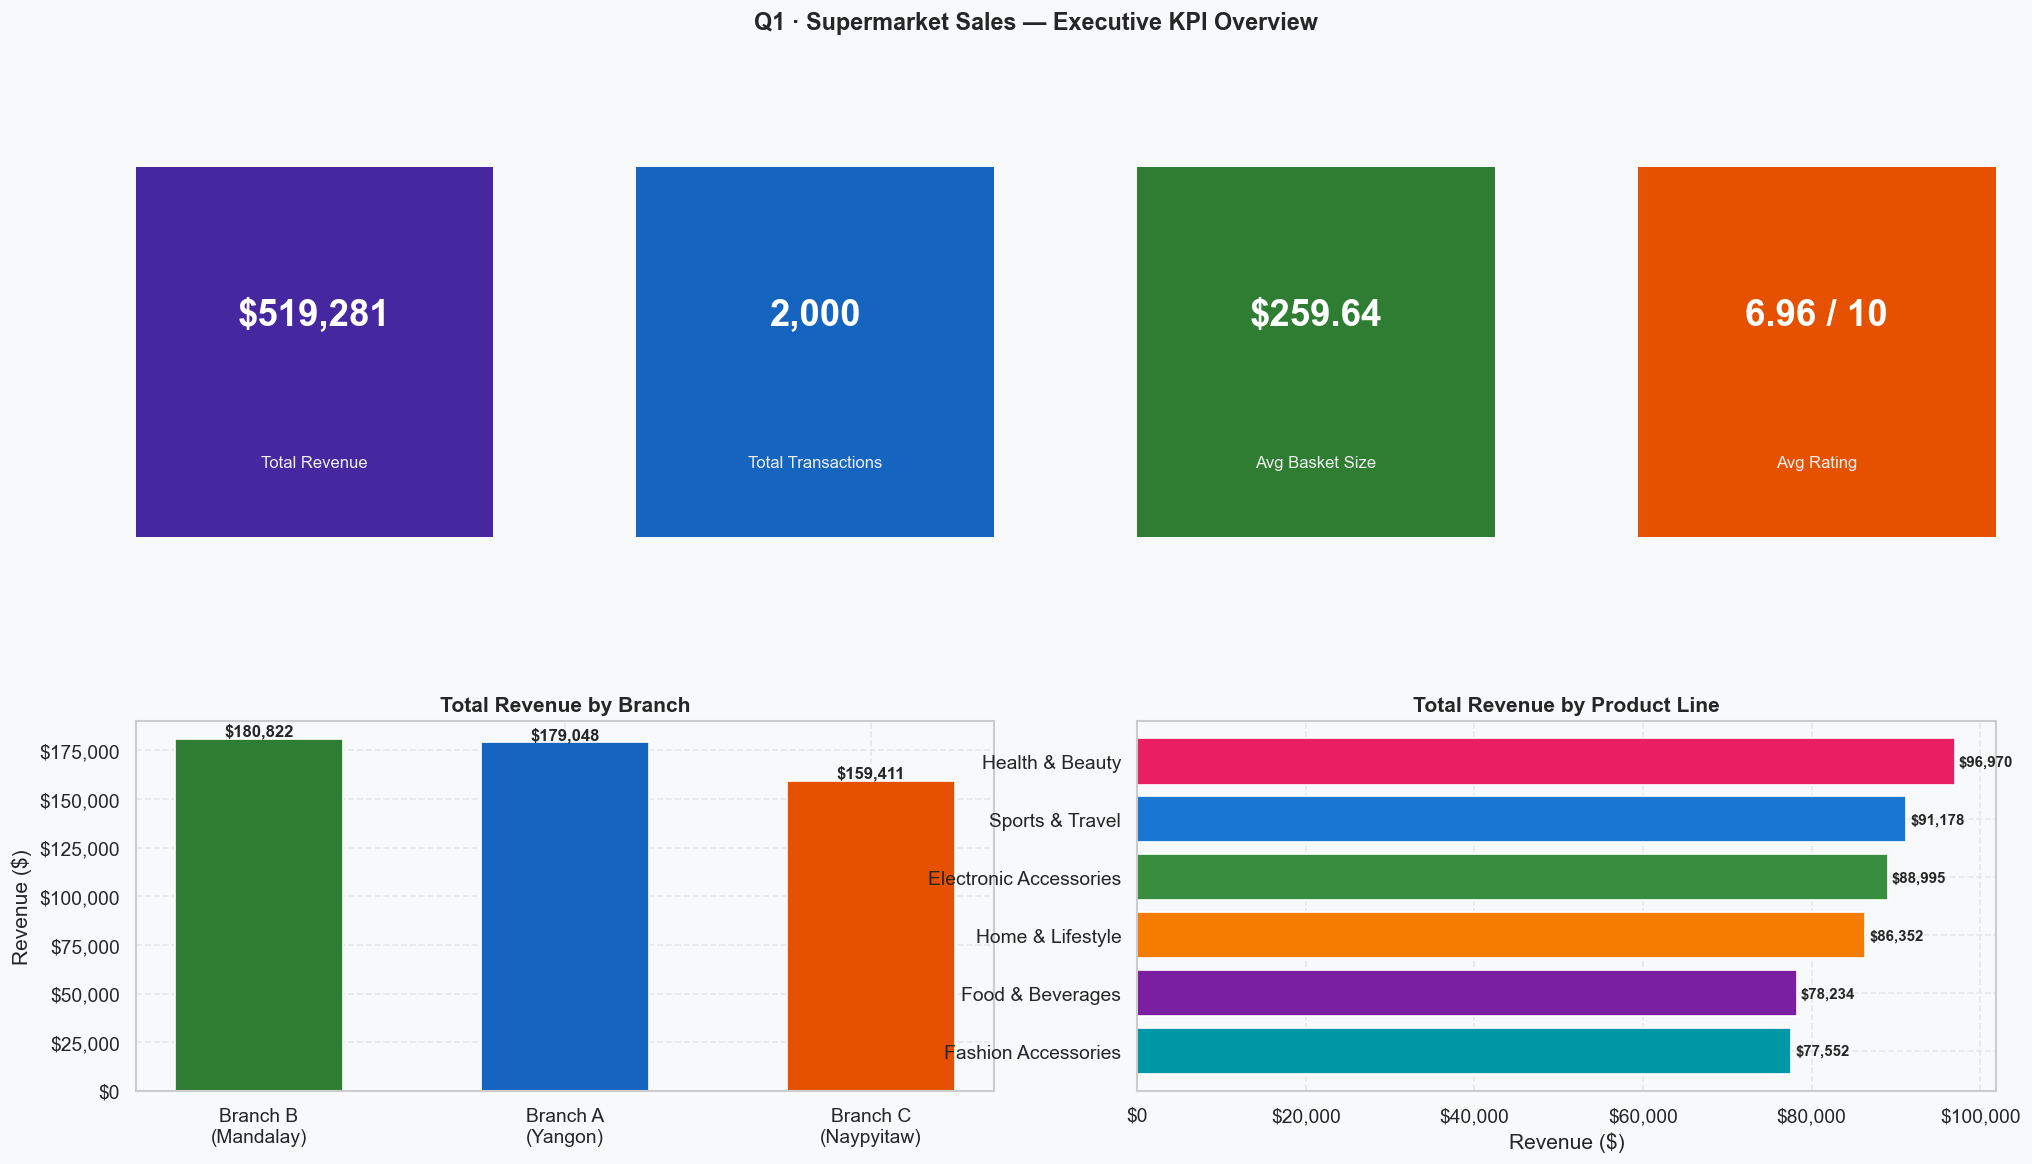

Total Revenue     : $519,280.69
Total Transactions: 2,000
Avg Basket        : $259.64
Median Basket     : $258.04
Highest Invoice   : $499.91


In [7]:
fig = plt.figure(figsize=(20, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.50, wspace=0.40)

# ── KPI Tiles ─────────────────────────────────────────────────────────────
kpis = [
    ('Total Revenue',    f"${df['Total'].sum():,.0f}",          '#4527A0'),
    ('Total Transactions', f"{len(df):,}",                      '#1565C0'),
    ('Avg Basket Size',  f"${df['Total'].mean():.2f}",          '#2E7D32'),
    ('Avg Rating',       f"{df['Rating'].mean():.2f} / 10",     '#E65100'),
]
for i, (label, val, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(color)
    ax.text(0.5, 0.60, val,   ha='center', va='center',
            fontsize=22, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.20, label, ha='center', va='center',
            fontsize=10, color='#EEEEEE', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)

# ── Revenue by Branch ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0:2])
branch_rev = df.groupby('Branch')['Total'].sum().sort_values(ascending=False)
colors_b = [BRANCH_COLORS[b] for b in branch_rev.index]
bars = ax1.bar(
    [f'Branch {b}\n({CITY_MAP[b]})' for b in branch_rev.index],
    branch_rev.values, color=colors_b, edgecolor='white', width=0.55
)
for bar, val in zip(bars, branch_rev.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
             f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_title('Total Revenue by Branch', fontweight='bold')
ax1.set_ylabel('Revenue ($)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# ── Revenue by Product Line ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 2:4])
prod_rev = df.groupby('Product_Line')['Total'].sum().sort_values()
colors_p  = [PRODUCT_COLORS[p] for p in prod_rev.index]
bars2 = ax2.barh(prod_rev.index, prod_rev.values, color=colors_p, edgecolor='white')
for bar, val in zip(bars2, prod_rev.values):
    ax2.text(bar.get_width()+500, bar.get_y()+bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=9, fontweight='bold')
ax2.set_title('Total Revenue by Product Line', fontweight='bold')
ax2.set_xlabel('Revenue ($)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

fig.suptitle('Q1 · Supermarket Sales — Executive KPI Overview',
             fontweight='bold', fontsize=14, y=1.01)
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q1_kpi_overview.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f'Total Revenue     : ${df.Total.sum():,.2f}')
print(f'Total Transactions: {len(df):,}')
print(f'Avg Basket        : ${df.Total.mean():.2f}')
print(f'Median Basket     : ${df.Total.median():.2f}')
print(f'Highest Invoice   : ${df.Total.max():.2f}')


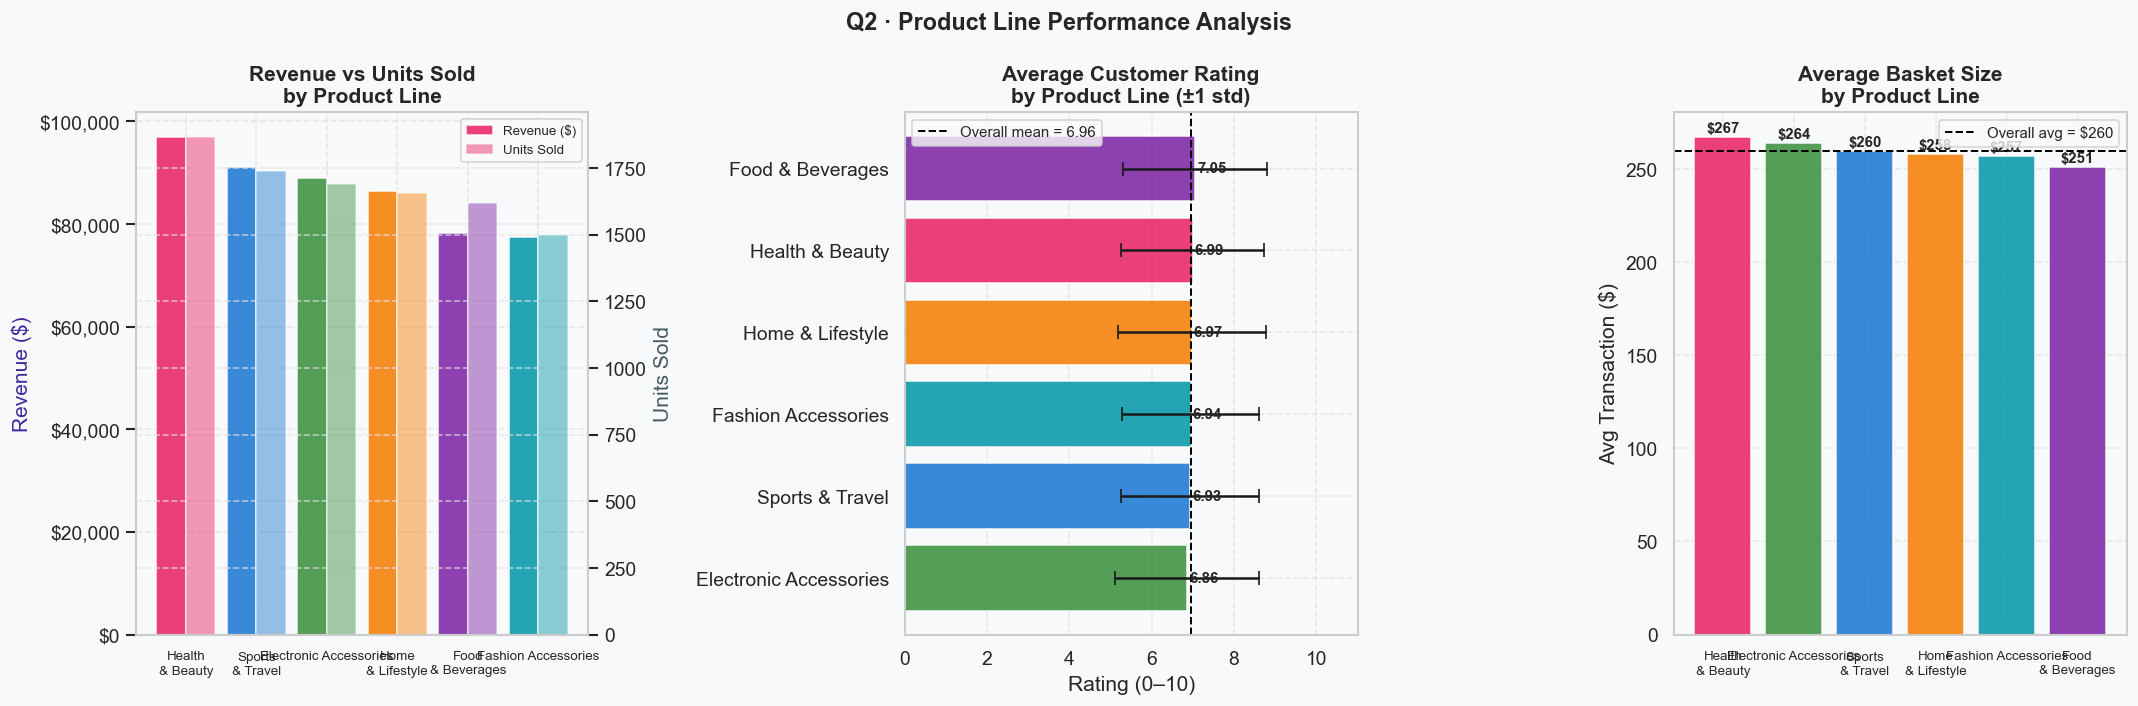

── Product Line Summary ──────────────────────────────────────────
                         Revenue   Qty  Txns    Avg_Bill  Avg_Rating
Product_Line                                                        
Health & Beauty         96970.32  1866   363  267.135868        6.99
Sports & Travel         91177.89  1737   351  259.766068        6.93
Electronic Accessories  88995.19  1691   337  264.080682        6.86
Home & Lifestyle        86351.63  1654   335  257.766060        6.97
Food & Beverages        78233.94  1618   312  250.749808        7.05
Fashion Accessories     77551.72  1500   302  256.793775        6.94


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Revenue + quantity dual bar ───────────────────────────────────────────
ax = axes[0]
prod_stats = df.groupby('Product_Line').agg(
    Revenue  = ('Total',    'sum'),
    Qty      = ('Quantity', 'sum'),
    Txns     = ('Invoice_ID','count'),
    Avg_Bill = ('Total',    'mean'),
).sort_values('Revenue', ascending=False)

x     = np.arange(len(prod_stats))
width = 0.42
colors_prod = [PRODUCT_COLORS[p] for p in prod_stats.index]
bars1 = ax.bar(x - width/2, prod_stats['Revenue'], width,
               color=colors_prod, alpha=0.85, edgecolor='white', label='Revenue ($)')
ax2t  = ax.twinx()
bars2 = ax2t.bar(x + width/2, prod_stats['Qty'], width,
                 color=colors_prod, alpha=0.45, edgecolor='white', label='Units Sold')
ax.set_xticks(x)
ax.set_xticklabels([p.replace(' & ', '\n& ') for p in prod_stats.index],
                   fontsize=8, ha='center')
ax.set_title('Revenue vs Units Sold\nby Product Line', fontweight='bold')
ax.set_ylabel('Revenue ($)', color='#4527A0')
ax2t.set_ylabel('Units Sold', color='#455A64')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2t.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper right')

# ── Average rating by product line ───────────────────────────────────────
ax3 = axes[1]
prod_rating = df.groupby('Product_Line')['Rating'].agg(['mean','std']).sort_values('mean',ascending=False)
colors_r    = [PRODUCT_COLORS[p] for p in prod_rating.index]
bars_r = ax3.barh(prod_rating.index[::-1], prod_rating['mean'].values[::-1],
                   xerr=prod_rating['std'].values[::-1],
                   color=colors_r[::-1], edgecolor='white',
                   alpha=0.85, capsize=4)
ax3.axvline(df['Rating'].mean(), color='black', linestyle='--', linewidth=1.2,
            label=f'Overall mean = {df.Rating.mean():.2f}')
for bar, val in zip(bars_r, prod_rating['mean'].values[::-1]):
    ax3.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9, fontweight='bold')
ax3.set_title('Average Customer Rating\nby Product Line (±1 std)', fontweight='bold')
ax3.set_xlabel('Rating (0–10)')
ax3.legend(fontsize=9)
ax3.set_xlim(0, 11)

# ── Avg basket value by product line ─────────────────────────────────────
ax4 = axes[2]
prod_basket = df.groupby('Product_Line')['Total'].mean().sort_values(ascending=False)
colors_bask = [PRODUCT_COLORS[p] for p in prod_basket.index]
bars_bask = ax4.bar(
    [p.replace(' & ', '\n& ') for p in prod_basket.index],
    prod_basket.values, color=colors_bask, edgecolor='white', alpha=0.85
)
for bar, val in zip(bars_bask, prod_basket.values):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'${val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax4.axhline(df['Total'].mean(), color='black', linestyle='--', linewidth=1.2,
            label=f'Overall avg = ${df.Total.mean():.0f}')
ax4.set_title('Average Basket Size\nby Product Line', fontweight='bold')
ax4.set_ylabel('Avg Transaction ($)')
ax4.legend(fontsize=9)
ax4.tick_params(axis='x', labelsize=8)

fig.suptitle('Q2 · Product Line Performance Analysis',
             fontweight='bold', fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'figures', 'q2_product_line_analysis.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('── Product Line Summary ──────────────────────────────────────────')
print(prod_stats.assign(Avg_Rating=df.groupby('Product_Line')['Rating'].mean().round(2))
      .to_string())


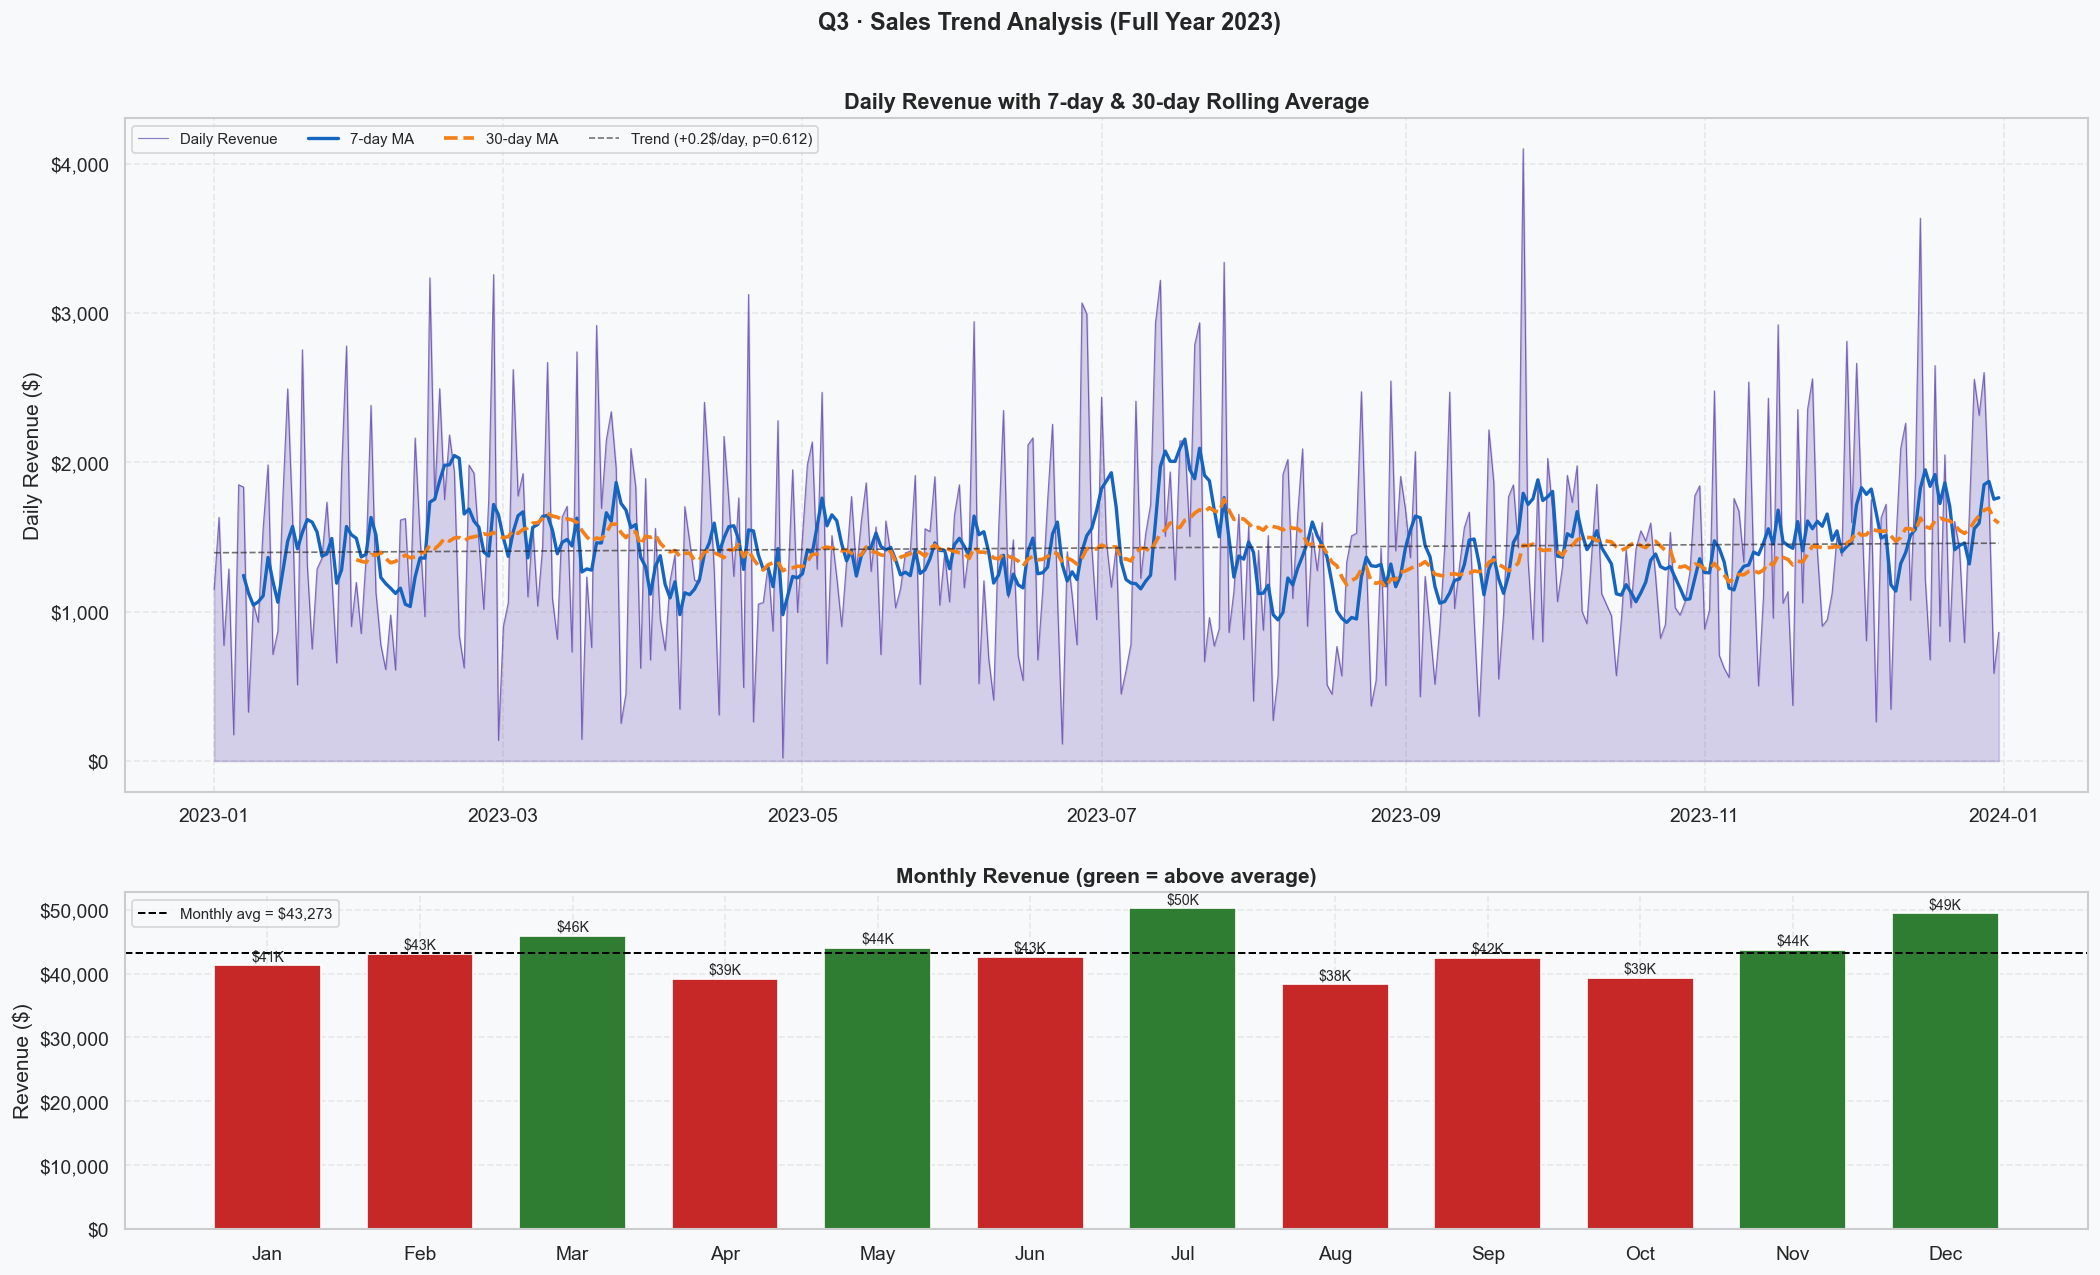

Best month  : Jul  ($50,184)
Worst month : Aug  ($38,313)
Trend slope : +0.18 $/day  (R²=0.001)


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(18, 11),
                          gridspec_kw={'height_ratios': [2, 1]})

# ── Daily revenue + 7-day rolling avg ────────────────────────────────────
ax = axes[0]
daily = df.groupby('Date')['Total'].sum()
roll7 = daily.rolling(7).mean()
roll30= daily.rolling(30).mean()

ax.fill_between(daily.index, daily.values, alpha=0.2, color=PAL['revenue'])
ax.plot(daily.index, daily.values, color=PAL['revenue'], linewidth=0.7,
        alpha=0.6, label='Daily Revenue')
ax.plot(roll7.index,  roll7.values,  color=PAL['A'],      linewidth=2.0, label='7-day MA')
ax.plot(roll30.index, roll30.values, color=PAL['highlight'], linewidth=2.2,
        linestyle='--', label='30-day MA')

# Linear trend
x_num = np.arange(len(daily))
sl, ic, r, p, _ = stats.linregress(x_num, daily.values)
trend_y = sl * x_num + ic
ax.plot(daily.index, trend_y, 'k--', linewidth=1.0, alpha=0.6,
        label=f'Trend ({sl:+.1f}$/day, p={p:.3f})')

ax.set_title('Daily Revenue with 7-day & 30-day Rolling Average',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Daily Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.legend(fontsize=9, ncol=4)

# ── Monthly revenue bar chart ─────────────────────────────────────────────
ax2 = axes[1]
monthly = df.groupby('Month')['Total'].sum()
monthly_avg = monthly.mean()
bar_colors = [PAL['positive'] if v >= monthly_avg else PAL['negative']
              for v in monthly.values]
bars = ax2.bar(range(1, 13), monthly.values,
               color=bar_colors, edgecolor='white', width=0.7)
ax2.axhline(monthly_avg, color='black', linestyle='--', linewidth=1.2,
            label=f'Monthly avg = ${monthly_avg:,.0f}')
for bar, val, m in zip(bars, monthly.values, range(1,13)):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+300,
             f'${val/1000:.0f}K', ha='center', va='bottom', fontsize=8.5)
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(MONTH_ABBR)
ax2.set_title('Monthly Revenue (green = above average)', fontweight='bold')
ax2.set_ylabel('Revenue ($)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax2.legend(fontsize=9)

fig.suptitle('Q3 · Sales Trend Analysis (Full Year 2023)',
             fontweight='bold', fontsize=14)
fig.tight_layout(pad=2)
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q3_sales_trend.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f'Best month  : {MONTH_ABBR[monthly.idxmax()-1]}  (${monthly.max():,.0f})')
print(f'Worst month : {MONTH_ABBR[monthly.idxmin()-1]}  (${monthly.min():,.0f})')
print(f'Trend slope : {sl:+.2f} $/day  (R²={r**2:.3f})')


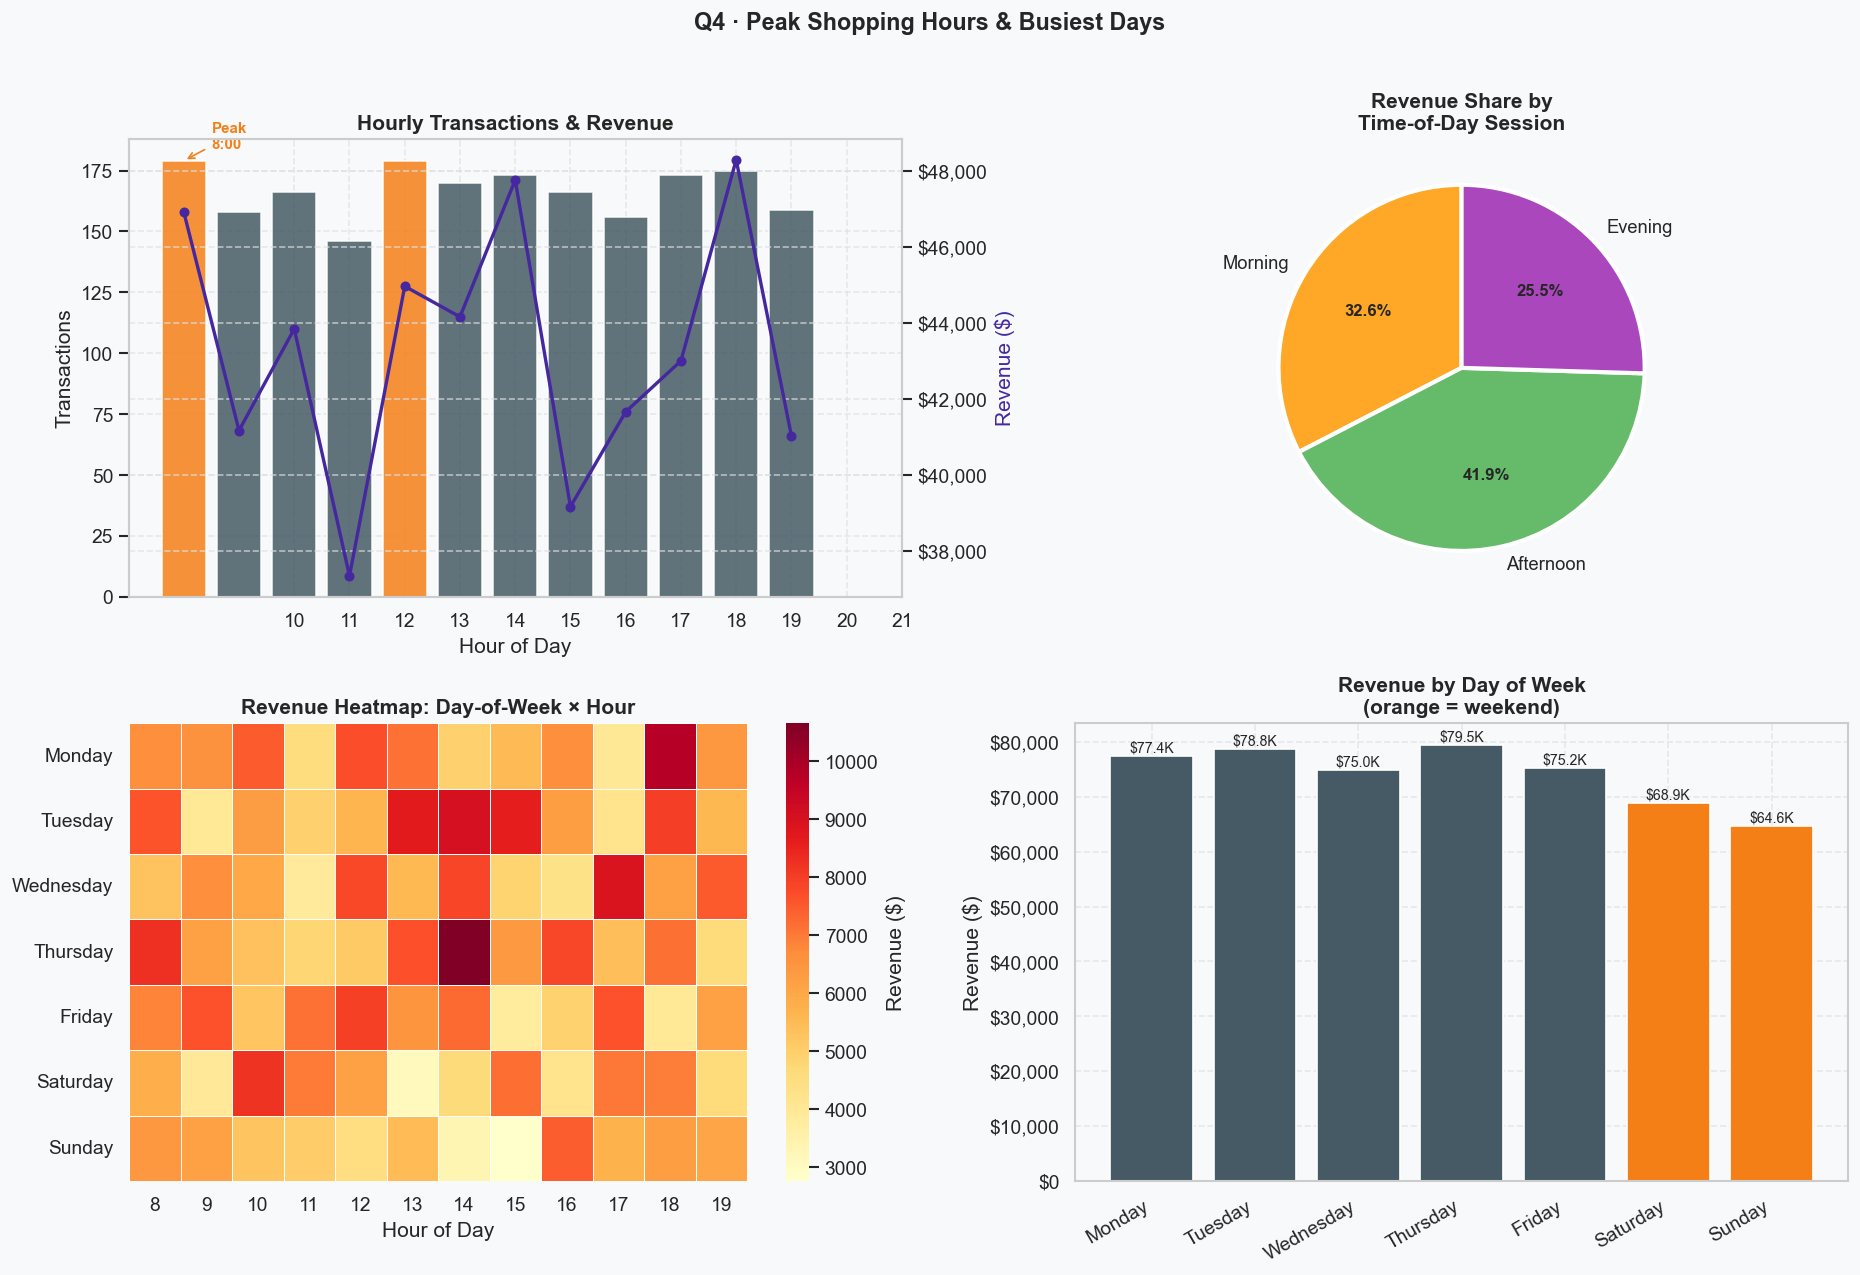

Peak hour       : 8:00  (179 transactions)
Peak day        : Thursday  ($79,450)
Avg weekend rev : $66,748/day
Avg weekday rev : $77,157/day


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── Hourly transaction count ──────────────────────────────────────────────
ax = axes[0,0]
hourly_txn = df.groupby('Hour').size()
hourly_rev = df.groupby('Hour')['Total'].sum()
bar_h = ax.bar(hourly_txn.index, hourly_txn.values,
               color=[PAL['highlight'] if v == hourly_txn.max() else PAL['neutral']
                      for v in hourly_txn.values],
               edgecolor='white', alpha=0.85)
ax2t  = ax.twinx()
ax2t.plot(hourly_rev.index, hourly_rev.values, 'o-',
          color=PAL['revenue'], linewidth=2, markersize=5, label='Revenue ($)')
ax2t.set_ylabel('Revenue ($)', color=PAL['revenue'])
ax2t.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_title('Hourly Transactions & Revenue', fontweight='bold')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Transactions')
ax.set_xticks(range(10, 22))
peak_hour = hourly_txn.idxmax()
ax.annotate(f'Peak\n{peak_hour}:00',
            xy=(peak_hour, hourly_txn[peak_hour]),
            xytext=(peak_hour+0.5, hourly_txn[peak_hour]+5),
            fontsize=9, color=PAL['highlight'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=PAL['highlight']))

# ── Session revenue share ─────────────────────────────────────────────────
ax2 = axes[0,1]
session_order = ['Morning','Afternoon','Evening','Night']
sess_rev = df.groupby('Session')['Total'].agg(['sum','count'])\
             .reindex([s for s in session_order if s in df['Session'].unique()])
sess_colors = ['#FFA726','#66BB6A','#AB47BC','#42A5F5']
wedges, texts, autos = ax2.pie(
    sess_rev['sum'], labels=sess_rev.index,
    colors=sess_colors[:len(sess_rev)],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2.5},
    textprops={'fontsize':11}
)
for a in autos: a.set_fontsize(10); a.set_fontweight('bold')
ax2.set_title('Revenue Share by\nTime-of-Day Session', fontweight='bold')

# ── Day-of-week heatmap (revenue) ─────────────────────────────────────────
ax3 = axes[1,0]
dow_hour = df.groupby(['Day_of_Week','Hour'])['Total'].sum().unstack(fill_value=0)
dow_hour = dow_hour.reindex([d for d in DOW_ORDER if d in dow_hour.index])
sns.heatmap(dow_hour, cmap='YlOrRd', ax=ax3,
            cbar_kws={'label':'Revenue ($)'},
            linewidths=0.3, fmt='.0f')
ax3.set_title('Revenue Heatmap: Day-of-Week × Hour', fontweight='bold')
ax3.set_xlabel('Hour of Day'); ax3.set_ylabel('')

# ── Day-of-week bar ───────────────────────────────────────────────────────
ax4 = axes[1,1]
dow_txn  = df[df['Day_of_Week'].isin(DOW_ORDER)]\
             .groupby('Day_of_Week').size()\
             .reindex(DOW_ORDER, fill_value=0)
dow_rev  = df[df['Day_of_Week'].isin(DOW_ORDER)]\
             .groupby('Day_of_Week')['Total'].sum()\
             .reindex(DOW_ORDER, fill_value=0)
dow_cols = [PAL['highlight'] if d in ['Saturday','Sunday'] else PAL['neutral']
            for d in DOW_ORDER]
bars4 = ax4.bar(DOW_ORDER, dow_rev.values, color=dow_cols, edgecolor='white')
for bar, val in zip(bars4, dow_rev.values):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
             f'${val/1000:.1f}K', ha='center', va='bottom', fontsize=8.5)
ax4.set_title('Revenue by Day of Week\n(orange = weekend)', fontweight='bold')
ax4.set_ylabel('Revenue ($)')
ax4.set_xticklabels(DOW_ORDER, rotation=30, ha='right')
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

fig.suptitle('Q4 · Peak Shopping Hours & Busiest Days',
             fontweight='bold', fontsize=14)
fig.tight_layout(pad=2)
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q4_peak_hours.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f'Peak hour       : {peak_hour}:00  ({hourly_txn[peak_hour]} transactions)')
print(f'Peak day        : {dow_txn.idxmax()}  (${dow_rev[dow_txn.idxmax()]:,.0f})')
print(f'Avg weekend rev : ${dow_rev[["Saturday","Sunday"]].mean():,.0f}/day')
print(f'Avg weekday rev : ${dow_rev[["Monday","Tuesday","Wednesday","Thursday","Friday"]].mean():,.0f}/day')


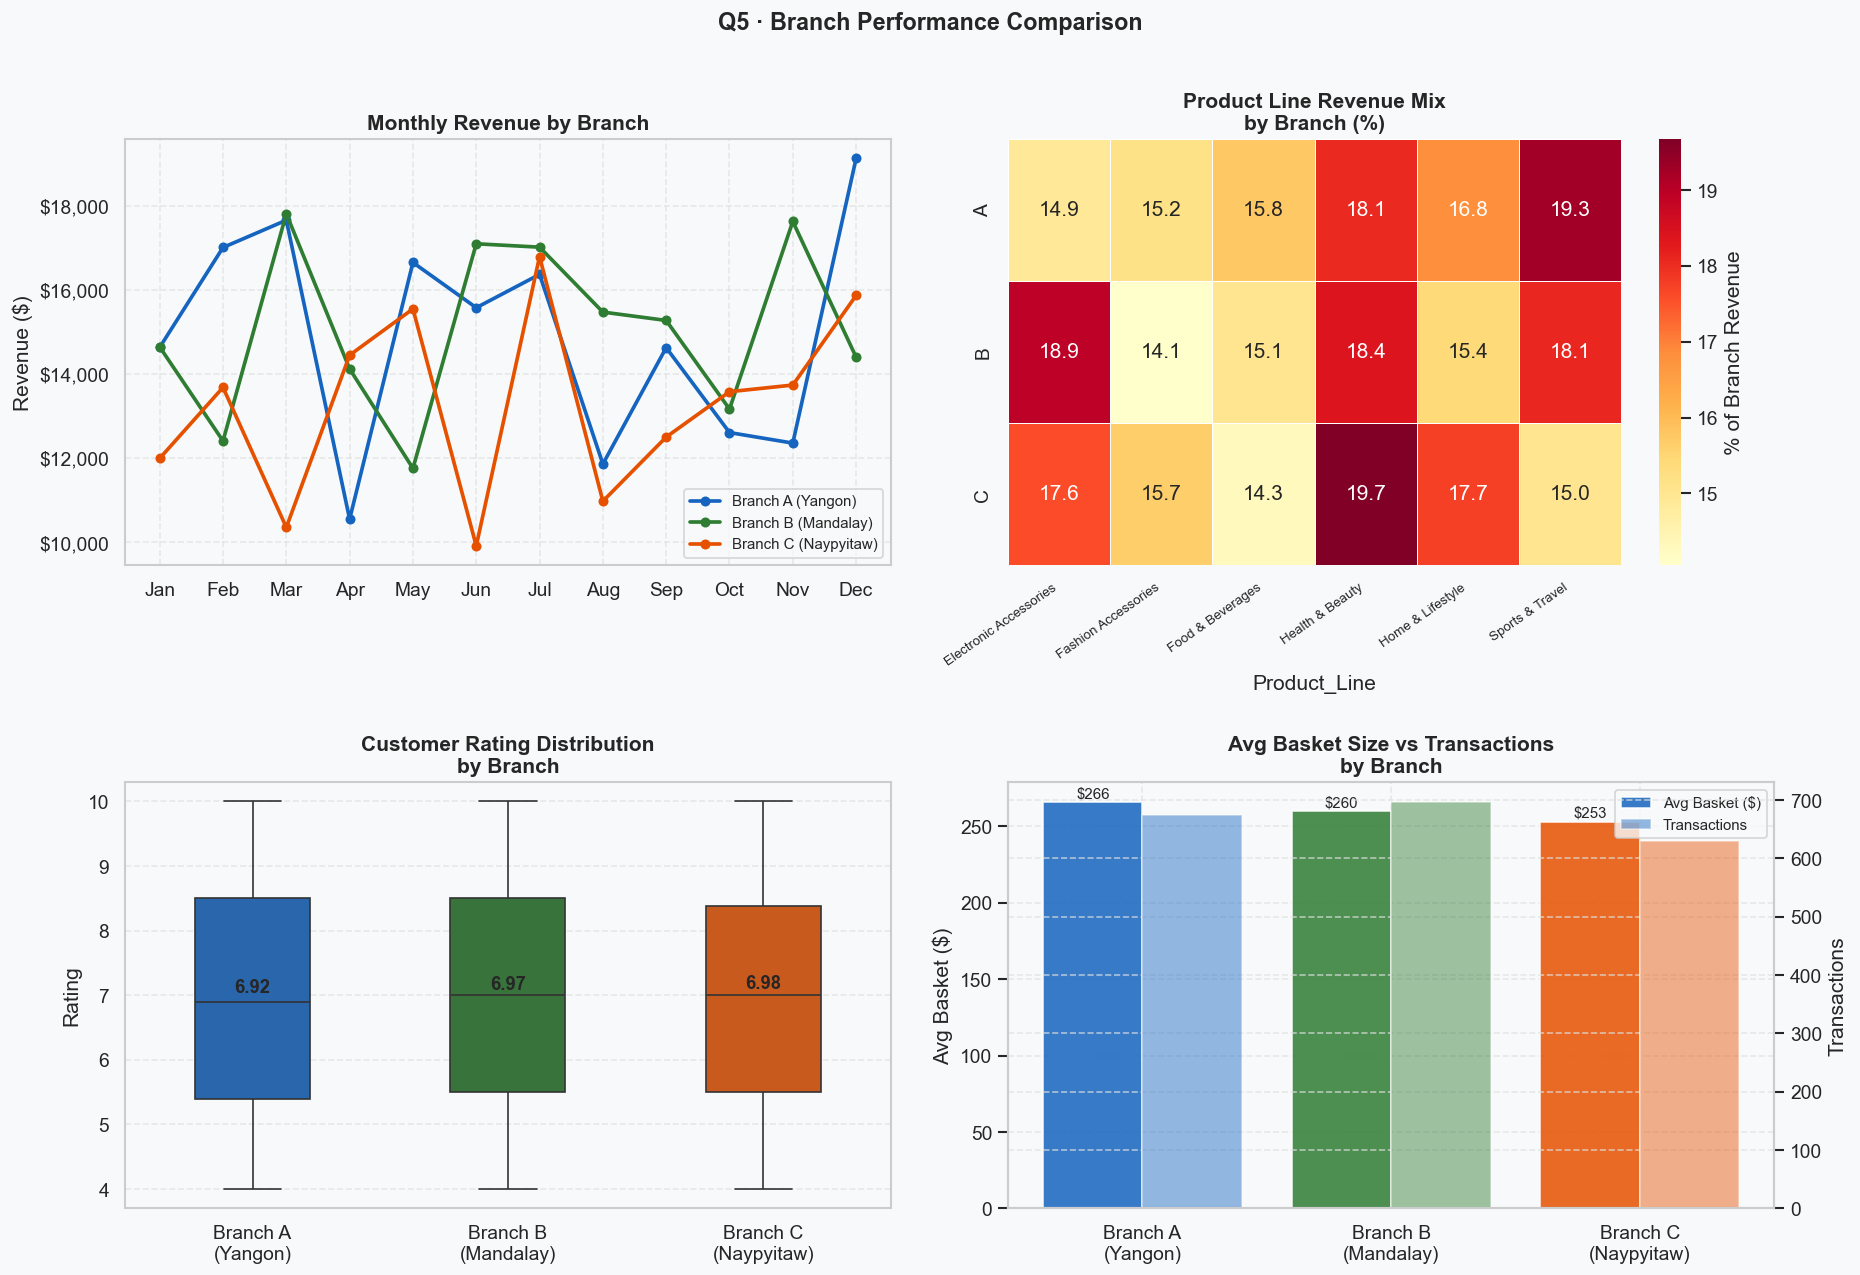

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── Monthly revenue by branch ─────────────────────────────────────────────
ax = axes[0,0]
branch_monthly = df.groupby(['Month','Branch'])['Total'].sum().unstack()
for branch in ['A','B','C']:
    if branch in branch_monthly.columns:
        ax.plot(MONTH_ABBR, branch_monthly[branch].reindex(range(1,13), fill_value=0).values,
                'o-', color=BRANCH_COLORS[branch],
                linewidth=2.2, markersize=5, label=f'Branch {branch} ({CITY_MAP[branch]})')
ax.set_title('Monthly Revenue by Branch', fontweight='bold')
ax.set_ylabel('Revenue ($)')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# ── Product mix heatmap by branch ─────────────────────────────────────────
ax2 = axes[0,1]
branch_prod = df.groupby(['Branch','Product_Line'])['Total'].sum().unstack()
branch_prod_pct = branch_prod.div(branch_prod.sum(axis=1), axis=0)*100
sns.heatmap(branch_prod_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax2, cbar_kws={'label':'% of Branch Revenue'})
ax2.set_title('Product Line Revenue Mix\nby Branch (%)', fontweight='bold')
ax2.set_ylabel('')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=35, ha='right', fontsize=8)

# ── Branch rating comparison ──────────────────────────────────────────────
ax3 = axes[1,0]
sns.boxplot(data=df, x='Branch', y='Rating',
            palette=BRANCH_COLORS, ax=ax3, width=0.45,
            order=['A','B','C'])
for i, branch in enumerate(['A','B','C']):
    m = df[df['Branch']==branch]['Rating'].mean()
    ax3.text(i, m+0.12, f'{m:.2f}', ha='center', fontsize=11, fontweight='bold')
ax3.set_title('Customer Rating Distribution\nby Branch', fontweight='bold')
ax3.set_xlabel('')
ax3.set_xticklabels([f'Branch {b}\n({CITY_MAP[b]})' for b in ['A','B','C']])

# ── Avg basket + transaction count ───────────────────────────────────────
ax4 = axes[1,1]
branch_basket = df.groupby('Branch').agg(
    Avg_Basket=('Total','mean'),
    Transactions=('Invoice_ID','count'),
    Total_Rev=('Total','sum'),
)
x = np.arange(3)
w = 0.40
bars_bask = ax4.bar(x - w/2, branch_basket['Avg_Basket'],
                    w, color=[BRANCH_COLORS[b] for b in branch_basket.index],
                    edgecolor='white', alpha=0.85, label='Avg Basket ($)')
ax4t = ax4.twinx()
bars_txn  = ax4t.bar(x + w/2, branch_basket['Transactions'],
                     w, color=[BRANCH_COLORS[b] for b in branch_basket.index],
                     edgecolor='white', alpha=0.45, label='Transactions')
ax4.set_xticks(x)
ax4.set_xticklabels([f'Branch {b}\n({CITY_MAP[b]})' for b in branch_basket.index])
ax4.set_title('Avg Basket Size vs Transactions\nby Branch', fontweight='bold')
ax4.set_ylabel('Avg Basket ($)'); ax4t.set_ylabel('Transactions')
for bar, val in zip(bars_bask, branch_basket['Avg_Basket']):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'${val:.0f}', ha='center', va='bottom', fontsize=9)
lines1,labels1 = ax4.get_legend_handles_labels()
lines2,labels2 = ax4t.get_legend_handles_labels()
ax4.legend(lines1+lines2,labels1+labels2,fontsize=9)

fig.suptitle('Q5 · Branch Performance Comparison',
             fontweight='bold', fontsize=14)
fig.tight_layout(pad=2)
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q5_branch_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()


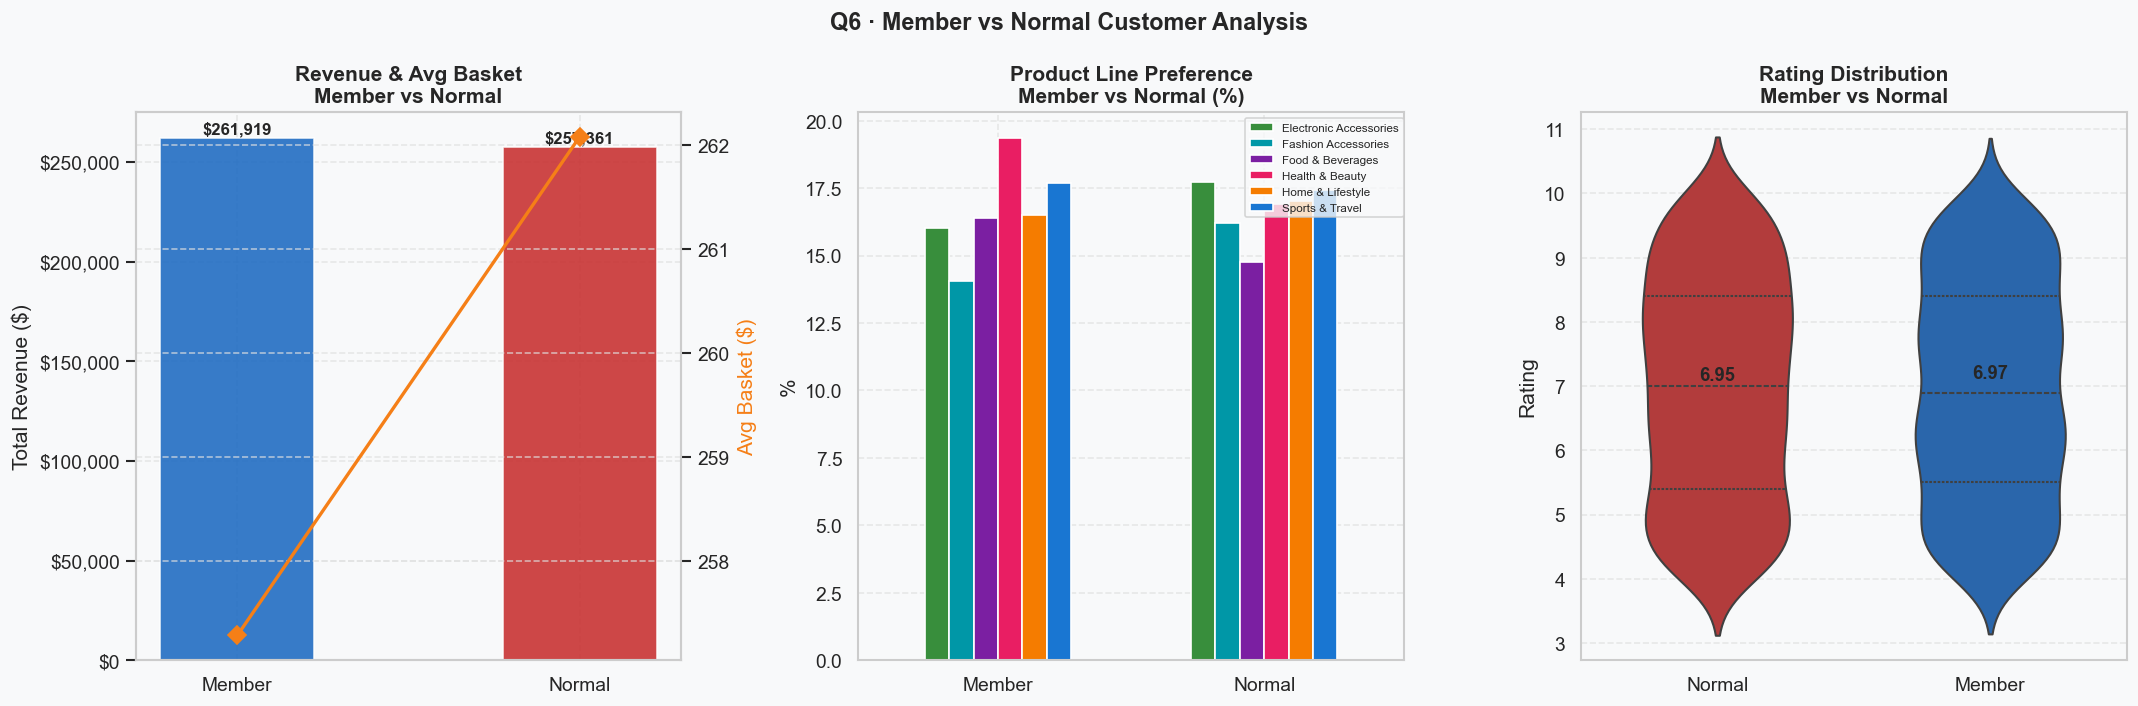

── Member vs Normal Summary ─────────────────────────────────
                Total                    Quantity              Rating         \
                 mean  median        sum     mean median   sum   mean median   
Customer_Type                                                                  
Member         257.29  255.38  261919.34     5.00    5.0  5094   6.95    6.9   
Normal         262.08  260.58  257361.35     5.06    5.0  4972   6.97    7.0   

                        Tax                  
                  sum  mean median      sum  
Customer_Type                                
Member         7070.4  5.55   5.48  5646.08  
Normal         6844.8  5.48   5.40  5379.41  

Mann-Whitney U test (spend): p=0.4359 → Not significant ❌


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
CTYPE_COLORS = {'Member': '#1565C0', 'Normal': '#C62828'}

# ── Revenue + transactions by customer type ───────────────────────────────
ax = axes[0]
ctype_stats = df.groupby('Customer_Type').agg(
    Revenue=('Total','sum'), Txns=('Invoice_ID','count'), Avg=('Total','mean'))
bars_rev = ax.bar(ctype_stats.index, ctype_stats['Revenue'],
                  color=[CTYPE_COLORS[c] for c in ctype_stats.index],
                  edgecolor='white', width=0.45, alpha=0.85)
ax2t = ax.twinx()
ax2t.plot(ctype_stats.index, ctype_stats['Avg'], 'D-',
          color=PAL['highlight'], linewidth=2, markersize=8, label='Avg Basket')
ax2t.set_ylabel('Avg Basket ($)', color=PAL['highlight'])
for bar, val in zip(bars_rev, ctype_stats['Revenue']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Revenue & Avg Basket\nMember vs Normal', fontweight='bold')
ax.set_ylabel('Total Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# ── Product preference by customer type ──────────────────────────────────
ax2 = axes[1]
ct_prod = df.groupby(['Customer_Type','Product_Line']).size().unstack(fill_value=0)
ct_prod_pct = ct_prod.div(ct_prod.sum(axis=1), axis=0)*100
ct_prod_pct.plot(kind='bar', ax=ax2,
                 color=[PRODUCT_COLORS[p] for p in ct_prod_pct.columns],
                 edgecolor='white', width=0.55)
ax2.set_title('Product Line Preference\nMember vs Normal (%)', fontweight='bold')
ax2.set_ylabel('%'); ax2.set_xlabel('')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(fontsize=7, loc='upper right', ncol=1,
           bbox_to_anchor=(1.01, 1))

# ── Rating + payment preference ───────────────────────────────────────────
ax3 = axes[2]
sns.violinplot(data=df, x='Customer_Type', y='Rating',
               palette=CTYPE_COLORS, ax=ax3, inner='quartile', width=0.55)
for i, ct in enumerate(['Member','Normal']):
    m = df[df['Customer_Type']==ct]['Rating'].mean()
    ax3.text(i, m+0.15, f'{m:.2f}', ha='center', fontsize=11, fontweight='bold')
ax3.set_title('Rating Distribution\nMember vs Normal', fontweight='bold')
ax3.set_xlabel('')

fig.suptitle('Q6 · Member vs Normal Customer Analysis',
             fontweight='bold', fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q6_member_vs_normal.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('── Member vs Normal Summary ─────────────────────────────────')
print(df.groupby('Customer_Type')[['Total','Quantity','Rating','Tax']]
       .agg(['mean','median','sum']).round(2))

# Statistical test
m_spend = df[df['Customer_Type']=='Member']['Total']
n_spend = df[df['Customer_Type']=='Normal']['Total']
stat, p = stats.mannwhitneyu(m_spend, n_spend, alternative='two-sided')
print(f'\nMann-Whitney U test (spend): p={p:.4f} → '
      f'{"Significant ✅" if p<0.05 else "Not significant ❌"}')


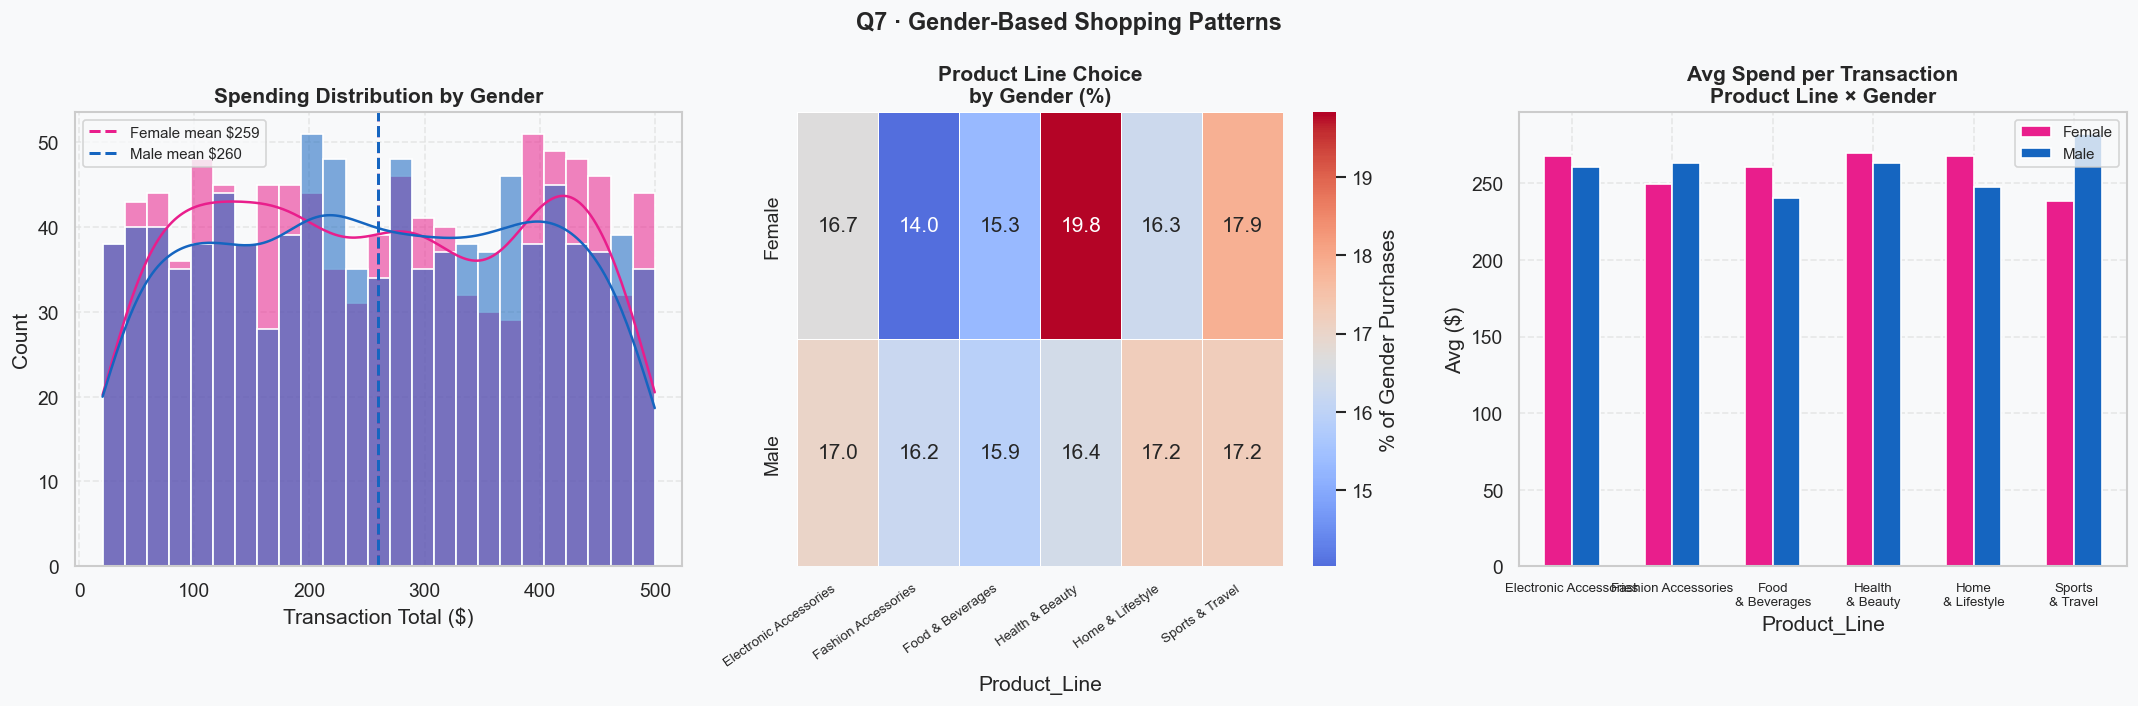

Female avg spend: $259.41  |  Male avg spend: $259.88
Mann-Whitney p=0.9356 → Not significant ❌


In [16]:
GENDER_COLORS = {'Female': '#E91E8C', 'Male': '#1565C0'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Spending distribution by gender ──────────────────────────────────────
ax = axes[0]
sns.histplot(data=df, x='Total', hue='Gender',
             palette=GENDER_COLORS, bins=25, alpha=0.55,
             kde=True, ax=ax, edgecolor='white')
for g, color in GENDER_COLORS.items():
    m = df[df['Gender']==g]['Total'].mean()
    ax.axvline(m, color=color, linestyle='--', linewidth=1.8,
               label=f'{g} mean ${m:.0f}')
ax.set_title('Spending Distribution by Gender', fontweight='bold')
ax.set_xlabel('Transaction Total ($)'); ax.set_ylabel('Count')
ax.legend(fontsize=9)

# ── Product line by gender heatmap ───────────────────────────────────────
ax2 = axes[1]
gender_prod = df.groupby(['Gender','Product_Line']).size().unstack(fill_value=0)
gender_pct  = gender_prod.div(gender_prod.sum(axis=1), axis=0)*100
sns.heatmap(gender_pct, annot=True, fmt='.1f', cmap='coolwarm',
            linewidths=0.5, ax=ax2, center=16.67,
            cbar_kws={'label':'% of Gender Purchases'})
ax2.set_title('Product Line Choice\nby Gender (%)', fontweight='bold')
ax2.set_ylabel('')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=35, ha='right', fontsize=8)

# ── Avg spend by product × gender ────────────────────────────────────────
ax3 = axes[2]
gender_prod_spend = df.groupby(['Product_Line','Gender'])['Total'].mean().unstack()
gender_prod_spend.plot(kind='bar', ax=ax3, color=list(GENDER_COLORS.values()),
                       edgecolor='white', width=0.55)
ax3.set_title('Avg Spend per Transaction\nProduct Line × Gender', fontweight='bold')
ax3.set_ylabel('Avg ($)')
ax3.set_xticklabels([p.replace(' & ', '\n& ') for p in gender_prod_spend.index],
                    rotation=0, fontsize=8)
ax3.legend(fontsize=9)

fig.suptitle('Q7 · Gender-Based Shopping Patterns',
             fontweight='bold', fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'figures', 'q7_gender_analysis.png'),
            dpi=150, bbox_inches='tight')
plt.show()

f_spend = df[df['Gender'] == 'Female']['Total']
m_spend = df[df['Gender'] == 'Male']['Total']
stat, p = stats.mannwhitneyu(f_spend, m_spend, alternative='two-sided')
print(f'Female avg spend: ${f_spend.mean():.2f}  |  Male avg spend: ${m_spend.mean():.2f}')
print(f'Mann-Whitney p={p:.4f} → {"Significant ✅" if p < 0.05 else "Not significant ❌"}')


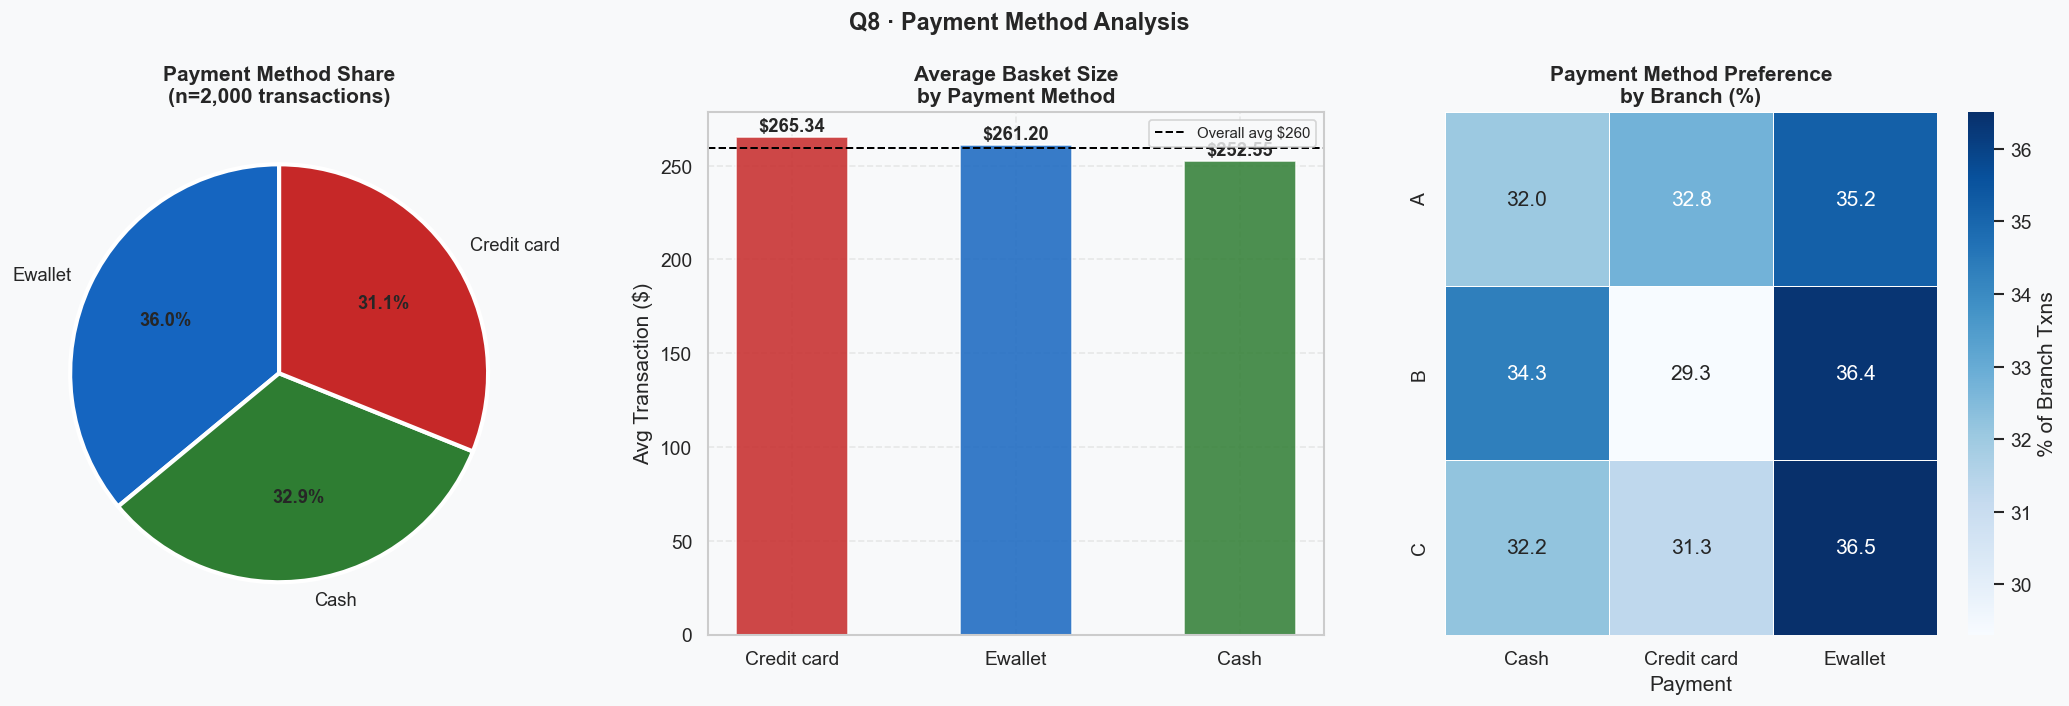

── Payment Method Stats ────────────────────────────────────
              Total       Quantity       Rating      
               mean count     mean count   mean count
Payment                                              
Cash         252.55   658     5.16   658   6.93   658
Credit card  265.34   622     5.04   622   6.87   622
Ewallet      261.20   720     4.91   720   7.06   720

Kruskal-Wallis (spend by payment): H=2.928, p=0.2313 → Not significant ❌


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Payment method pie ────────────────────────────────────────────────────
ax = axes[0]
pay_counts = df['Payment'].value_counts()
wedges, texts, autos = ax.pie(
    pay_counts.values, labels=pay_counts.index,
    colors=[PAYMENT_COLORS[p] for p in pay_counts.index],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2.5},
    textprops={'fontsize':11}
)
for a in autos: a.set_fontweight('bold')
ax.set_title(f'Payment Method Share\n(n={len(df):,} transactions)', fontweight='bold')

# ── Avg basket by payment ─────────────────────────────────────────────────
ax2 = axes[1]
pay_stats = df.groupby('Payment').agg(
    Avg_Total=('Total','mean'),
    Avg_Qty  =('Quantity','mean'),
    Count    =('Invoice_ID','count'),
).sort_values('Avg_Total', ascending=False)
bars = ax2.bar(pay_stats.index, pay_stats['Avg_Total'],
               color=[PAYMENT_COLORS[p] for p in pay_stats.index],
               edgecolor='white', alpha=0.85, width=0.5)
ax2.axhline(df['Total'].mean(), color='black', linestyle='--', linewidth=1.2,
            label=f'Overall avg ${df.Total.mean():.0f}')
for bar, val in zip(bars, pay_stats['Avg_Total']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'${val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_title('Average Basket Size\nby Payment Method', fontweight='bold')
ax2.set_ylabel('Avg Transaction ($)')
ax2.legend(fontsize=9)

# ── Payment method by branch heatmap ─────────────────────────────────────
ax3 = axes[2]
branch_pay = df.groupby(['Branch','Payment']).size().unstack(fill_value=0)
branch_pay_pct = branch_pay.div(branch_pay.sum(axis=1),axis=0)*100
sns.heatmap(branch_pay_pct, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=ax3, cbar_kws={'label':'% of Branch Txns'})
ax3.set_title('Payment Method Preference\nby Branch (%)', fontweight='bold')
ax3.set_ylabel('')

fig.suptitle('Q8 · Payment Method Analysis',
             fontweight='bold', fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q8_payment_methods.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('── Payment Method Stats ────────────────────────────────────')
print(df.groupby('Payment')[['Total','Quantity','Rating']].agg(['mean','count']).round(2))
stat, p = stats.kruskal(*[df[df['Payment']==pm]['Total'] for pm in df['Payment'].unique()])
print(f'\nKruskal-Wallis (spend by payment): H={stat:.3f}, p={p:.4f} → '
      f'{"Significant ✅" if p<0.05 else "Not significant ❌"}')


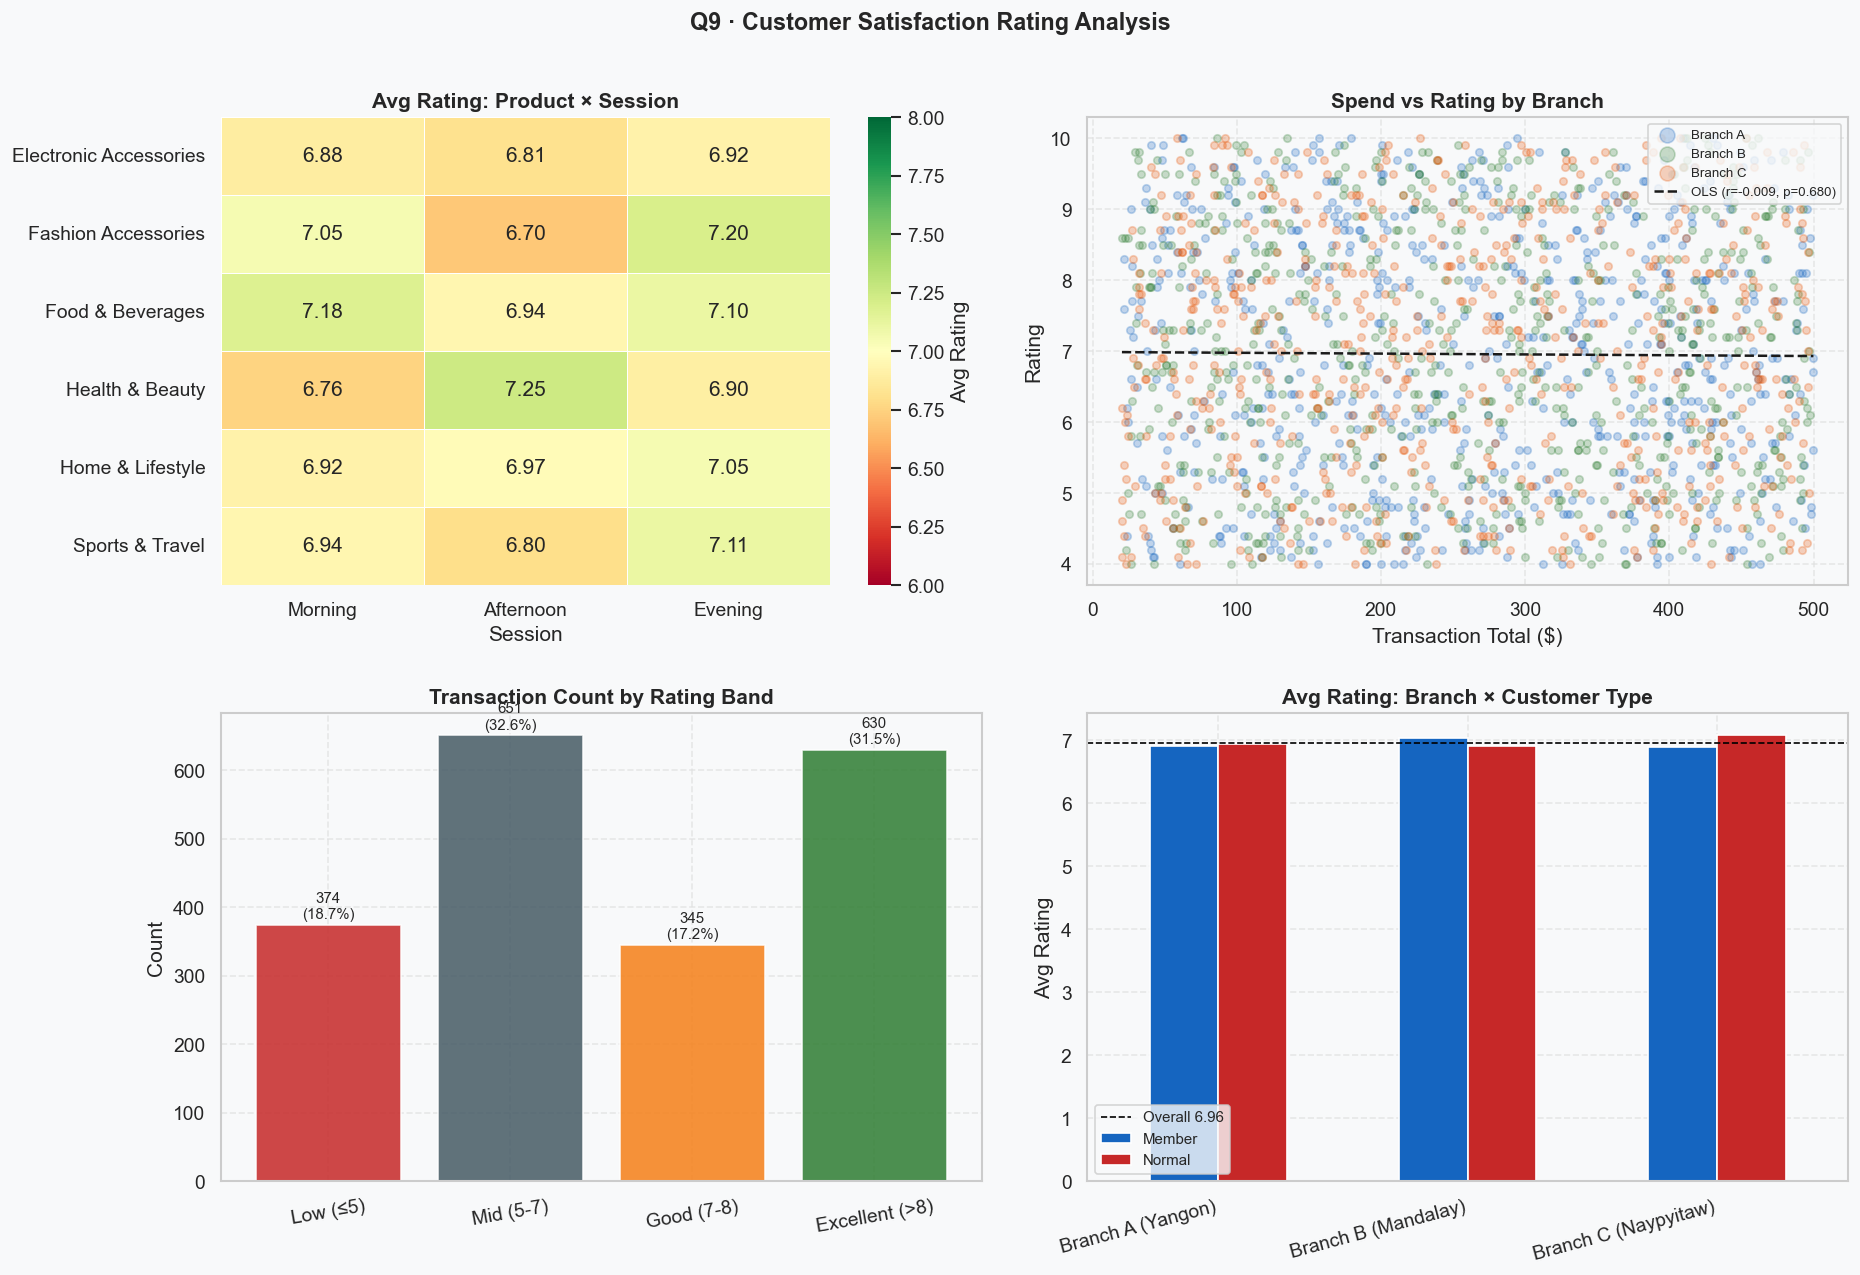


Correlation (Spend vs Rating): r=-0.0092, p=0.6802
Rating distribution:
Rating_Band
Low (≤5)          374
Mid (5-7)         651
Good (7-8)        345
Excellent (>8)    630
Name: count, dtype: int64


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── Rating by product × session heatmap ──────────────────────────────────
ax = axes[0,0]
prod_sess_rating = df.groupby(['Product_Line','Session'])['Rating']\
                     .mean().unstack()\
                     .reindex(columns=[s for s in ['Morning','Afternoon','Evening','Night']
                                       if s in df['Session'].unique()])
sns.heatmap(prod_sess_rating, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=6, vmax=8, linewidths=0.5, ax=ax,
            cbar_kws={'label':'Avg Rating'})
ax.set_title('Avg Rating: Product × Session', fontweight='bold')
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# ── Rating vs Total spend scatter ─────────────────────────────────────────
ax2 = axes[0,1]
for branch in ['A','B','C']:
    sub = df[df['Branch']==branch]
    ax2.scatter(sub['Total'], sub['Rating'],
                c=BRANCH_COLORS[branch], alpha=0.25, s=20,
                label=f'Branch {branch}')
r, p = stats.pearsonr(df['Total'], df['Rating'])
sl, ic, *_ = stats.linregress(df['Total'], df['Rating'])
x_r = np.linspace(df['Total'].min(), df['Total'].max(), 100)
ax2.plot(x_r, sl*x_r+ic, 'k--', linewidth=1.5,
         label=f'OLS (r={r:.3f}, p={p:.3f})')
ax2.set_xlabel('Transaction Total ($)'); ax2.set_ylabel('Rating')
ax2.set_title('Spend vs Rating by Branch', fontweight='bold')
ax2.legend(fontsize=8, markerscale=2)

# ── Rating distribution by rating band ───────────────────────────────────
ax3 = axes[1,0]
band_order = ['Low (≤5)','Mid (5-7)','Good (7-8)','Excellent (>8)']
band_counts = df['Rating_Band'].value_counts().reindex(band_order, fill_value=0)
band_colors = [PAL['negative'], PAL['neutral'], PAL['highlight'], PAL['positive']]
bars = ax3.bar(band_counts.index, band_counts.values,
               color=band_colors, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, band_counts.values):
    pct = val/len(df)*100
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax3.set_title('Transaction Count by Rating Band', fontweight='bold')
ax3.set_ylabel('Count')
ax3.set_xticklabels(band_counts.index, rotation=10)

# ── Avg rating: branch × customer type ───────────────────────────────────
ax4 = axes[1,1]
branch_ct_rating = df.groupby(['Branch','Customer_Type'])['Rating'].mean().unstack()
branch_ct_rating.index = [f'Branch {b} ({CITY_MAP[b]})' for b in branch_ct_rating.index]
branch_ct_rating.plot(kind='bar', ax=ax4,
                      color=['#1565C0','#C62828'], edgecolor='white', width=0.55)
ax4.set_title('Avg Rating: Branch × Customer Type', fontweight='bold')
ax4.set_ylabel('Avg Rating'); ax4.set_xlabel('')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=15, ha='right')
ax4.axhline(df['Rating'].mean(), color='black', linestyle='--',
            linewidth=1, label=f'Overall {df.Rating.mean():.2f}')
ax4.legend(fontsize=9)

fig.suptitle('Q9 · Customer Satisfaction Rating Analysis',
             fontweight='bold', fontsize=14)
fig.tight_layout(pad=2)
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q9_rating_drivers.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f'\nCorrelation (Spend vs Rating): r={r:.4f}, p={p:.4f}')
print(f'Rating distribution:')
print(df['Rating_Band'].value_counts().reindex(band_order))


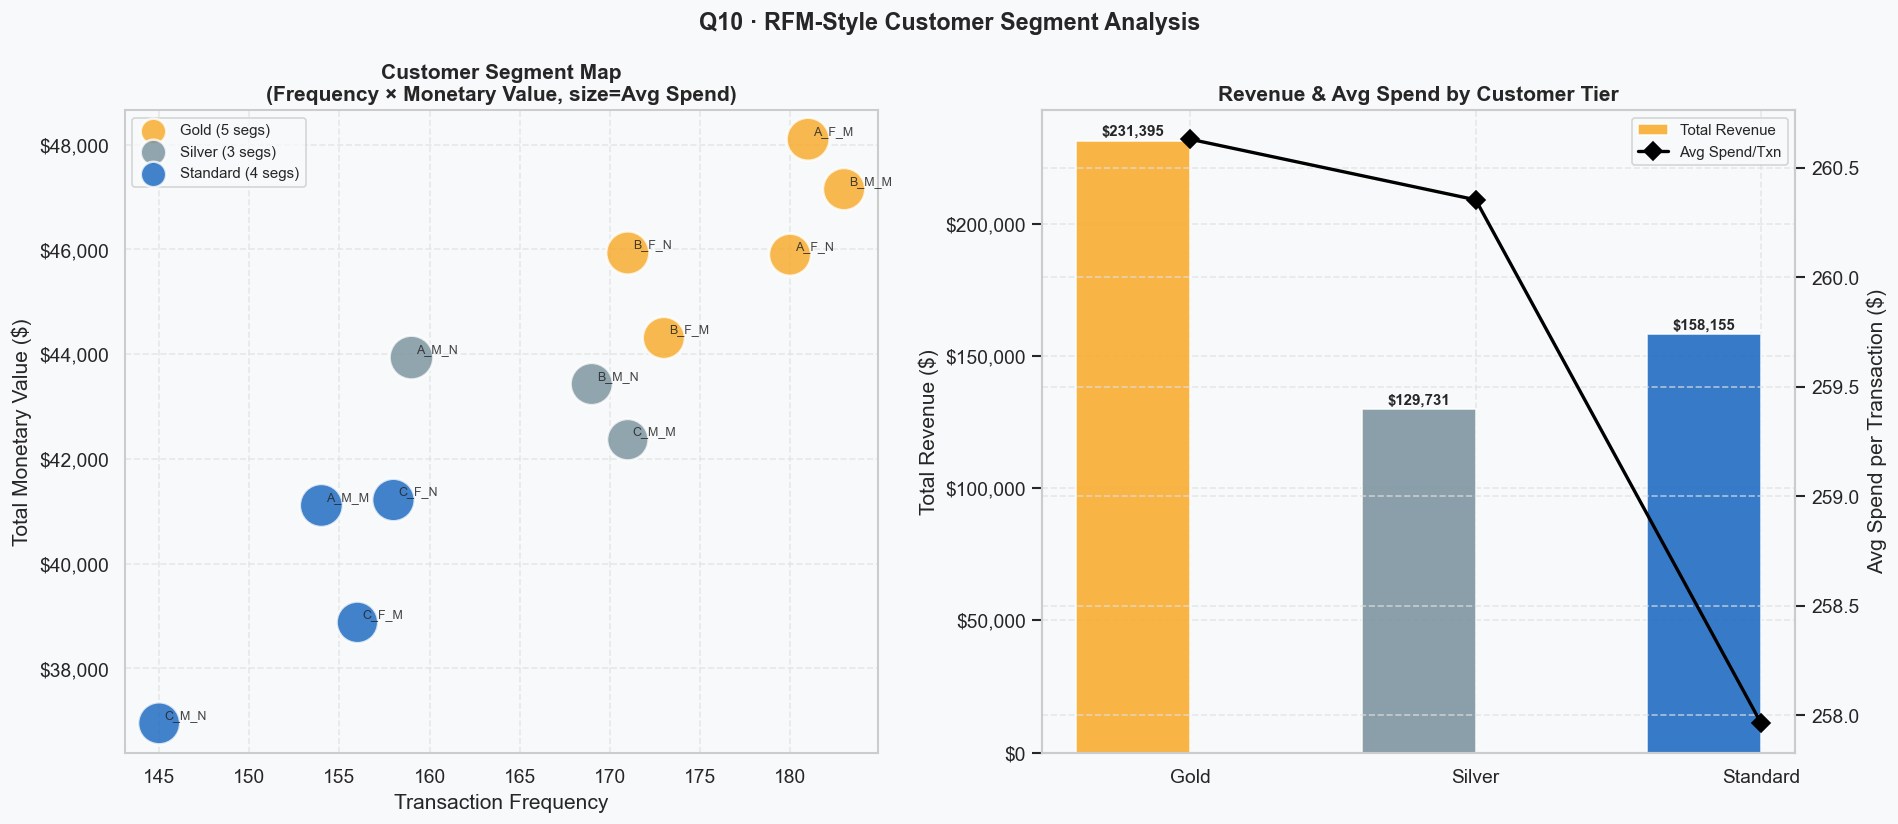


── Customer Segment Rankings (Top 10 by Revenue) ──────────
                  Frequency  Monetary  Avg_Spend  Avg_Rating      Tier
Customer_Segment                                                      
A_F_M                   181  48103.76     265.77        6.98      Gold
B_M_M                   183  47150.75     257.65        6.88      Gold
B_F_N                   171  45931.98     268.61        6.94      Gold
A_F_N                   180  45899.23     255.00        7.01      Gold
B_F_M                   173  44309.25     256.12        7.18      Gold
A_M_N                   159  43934.45     276.32        6.86    Silver
B_M_N                   169  43429.81     256.98        6.88    Silver
C_M_M                   171  42366.86     247.76        6.71    Silver
C_F_N                   158  41214.82     260.85        6.98  Standard
A_M_M                   154  41110.49     266.95        6.83  Standard


In [19]:
# ── RFM Proxy using Invoice_ID prefix as customer surrogate ──────────────
# (No unique customer IDs in dataset — use User proxy = Branch+Gender+CustomerType)
df['Customer_Segment'] = df['Branch'] + '_' + df['Gender'].str[0] + '_' + df['Customer_Type'].str[0]

seg_stats = df.groupby('Customer_Segment').agg(
    Frequency    = ('Invoice_ID', 'count'),
    Monetary     = ('Total',      'sum'),
    Avg_Spend    = ('Total',      'mean'),
    Avg_Rating   = ('Rating',     'mean'),
    Avg_Qty      = ('Quantity',   'mean'),
).sort_values('Monetary', ascending=False).round(2)

# Score: high frequency × high monetary = VIP
seg_stats['F_score'] = pd.qcut(seg_stats['Frequency'], 3, labels=[1,2,3]).astype(int)
seg_stats['M_score'] = pd.qcut(seg_stats['Monetary'],  3, labels=[1,2,3]).astype(int)
seg_stats['FM_score']= seg_stats['F_score'] + seg_stats['M_score']
seg_stats['Tier']    = pd.cut(seg_stats['FM_score'],
                               bins=[0,2,4,6],
                               labels=['Standard','Silver','Gold'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Frequency vs Monetary scatter ─────────────────────────────────────────
ax = axes[0]
tier_colors = {'Gold':'#F9A825','Silver':'#78909C','Standard':'#1565C0'}
for tier, color in tier_colors.items():
    sub = seg_stats[seg_stats['Tier']==tier]
    ax.scatter(sub['Frequency'], sub['Monetary'],
               s=sub['Avg_Spend']*2.5, c=color, alpha=0.8,
               edgecolors='white', linewidths=1.5,
               label=f'{tier} ({len(sub)} segs)')
for seg, row in seg_stats.iterrows():
    ax.annotate(seg, (row['Frequency'], row['Monetary']),
                fontsize=7.5, xytext=(3,3), textcoords='offset points', alpha=0.85)
ax.set_xlabel('Transaction Frequency')
ax.set_ylabel('Total Monetary Value ($)')
ax.set_title('Customer Segment Map\n(Frequency × Monetary Value, size=Avg Spend)',
             fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.legend(fontsize=9, markerscale=0.6)

# ── Segment tier summary bar ──────────────────────────────────────────────
ax2 = axes[1]
tier_summary = seg_stats.groupby('Tier').agg(
    Segments =('Frequency','count'),
    Total_Rev=('Monetary','sum'),
    Avg_Spend=('Avg_Spend','mean'),
).reindex(['Gold','Silver','Standard'])
x = np.arange(3)
w = 0.40
bars_rev = ax2.bar(x - w/2, tier_summary['Total_Rev'], w,
                   color=[tier_colors[t] for t in tier_summary.index],
                   edgecolor='white', alpha=0.85, label='Total Revenue')
ax2t = ax2.twinx()
ax2t.plot(x, tier_summary['Avg_Spend'], 'D-',
          color='black', linewidth=2, markersize=8, label='Avg Spend/Txn')
ax2t.set_ylabel('Avg Spend per Transaction ($)')
ax2.set_xticks(x)
ax2.set_xticklabels(tier_summary.index)
ax2.set_title('Revenue & Avg Spend by Customer Tier',
              fontweight='bold')
ax2.set_ylabel('Total Revenue ($)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
for bar, val in zip(bars_rev, tier_summary['Total_Rev']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000,
             f'${val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
lines1,labels1 = ax2.get_legend_handles_labels()
lines2,labels2 = ax2t.get_legend_handles_labels()
ax2.legend(lines1+lines2,labels1+labels2,fontsize=9)

fig.suptitle('Q10 · RFM-Style Customer Segment Analysis',
             fontweight='bold', fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q10_customer_segments.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('\n── Customer Segment Rankings (Top 10 by Revenue) ──────────')
print(seg_stats[['Frequency','Monetary','Avg_Spend','Avg_Rating','Tier']]
      .head(10).to_string())


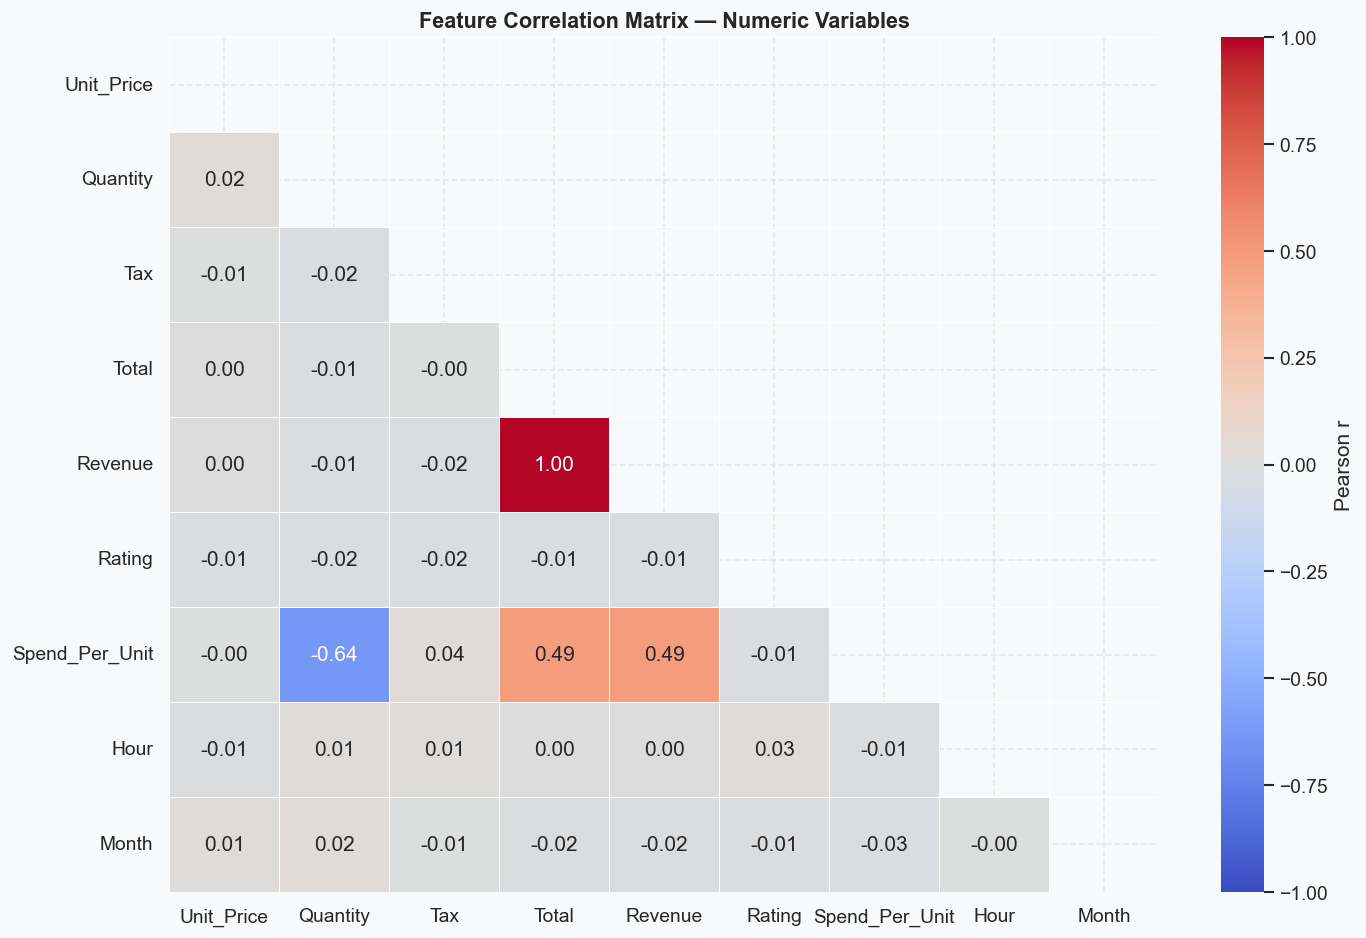

In [20]:
fig, ax = plt.subplots(figsize=(12, 8))
corr_cols = ['Unit_Price','Quantity','Tax','Total','Revenue',
             'Rating','Spend_Per_Unit','Hour','Month']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label':'Pearson r'}, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix — Numeric Variables',
             fontweight='bold', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','correlation_matrix.png'),
            dpi=150, bbox_inches='tight')
plt.show()


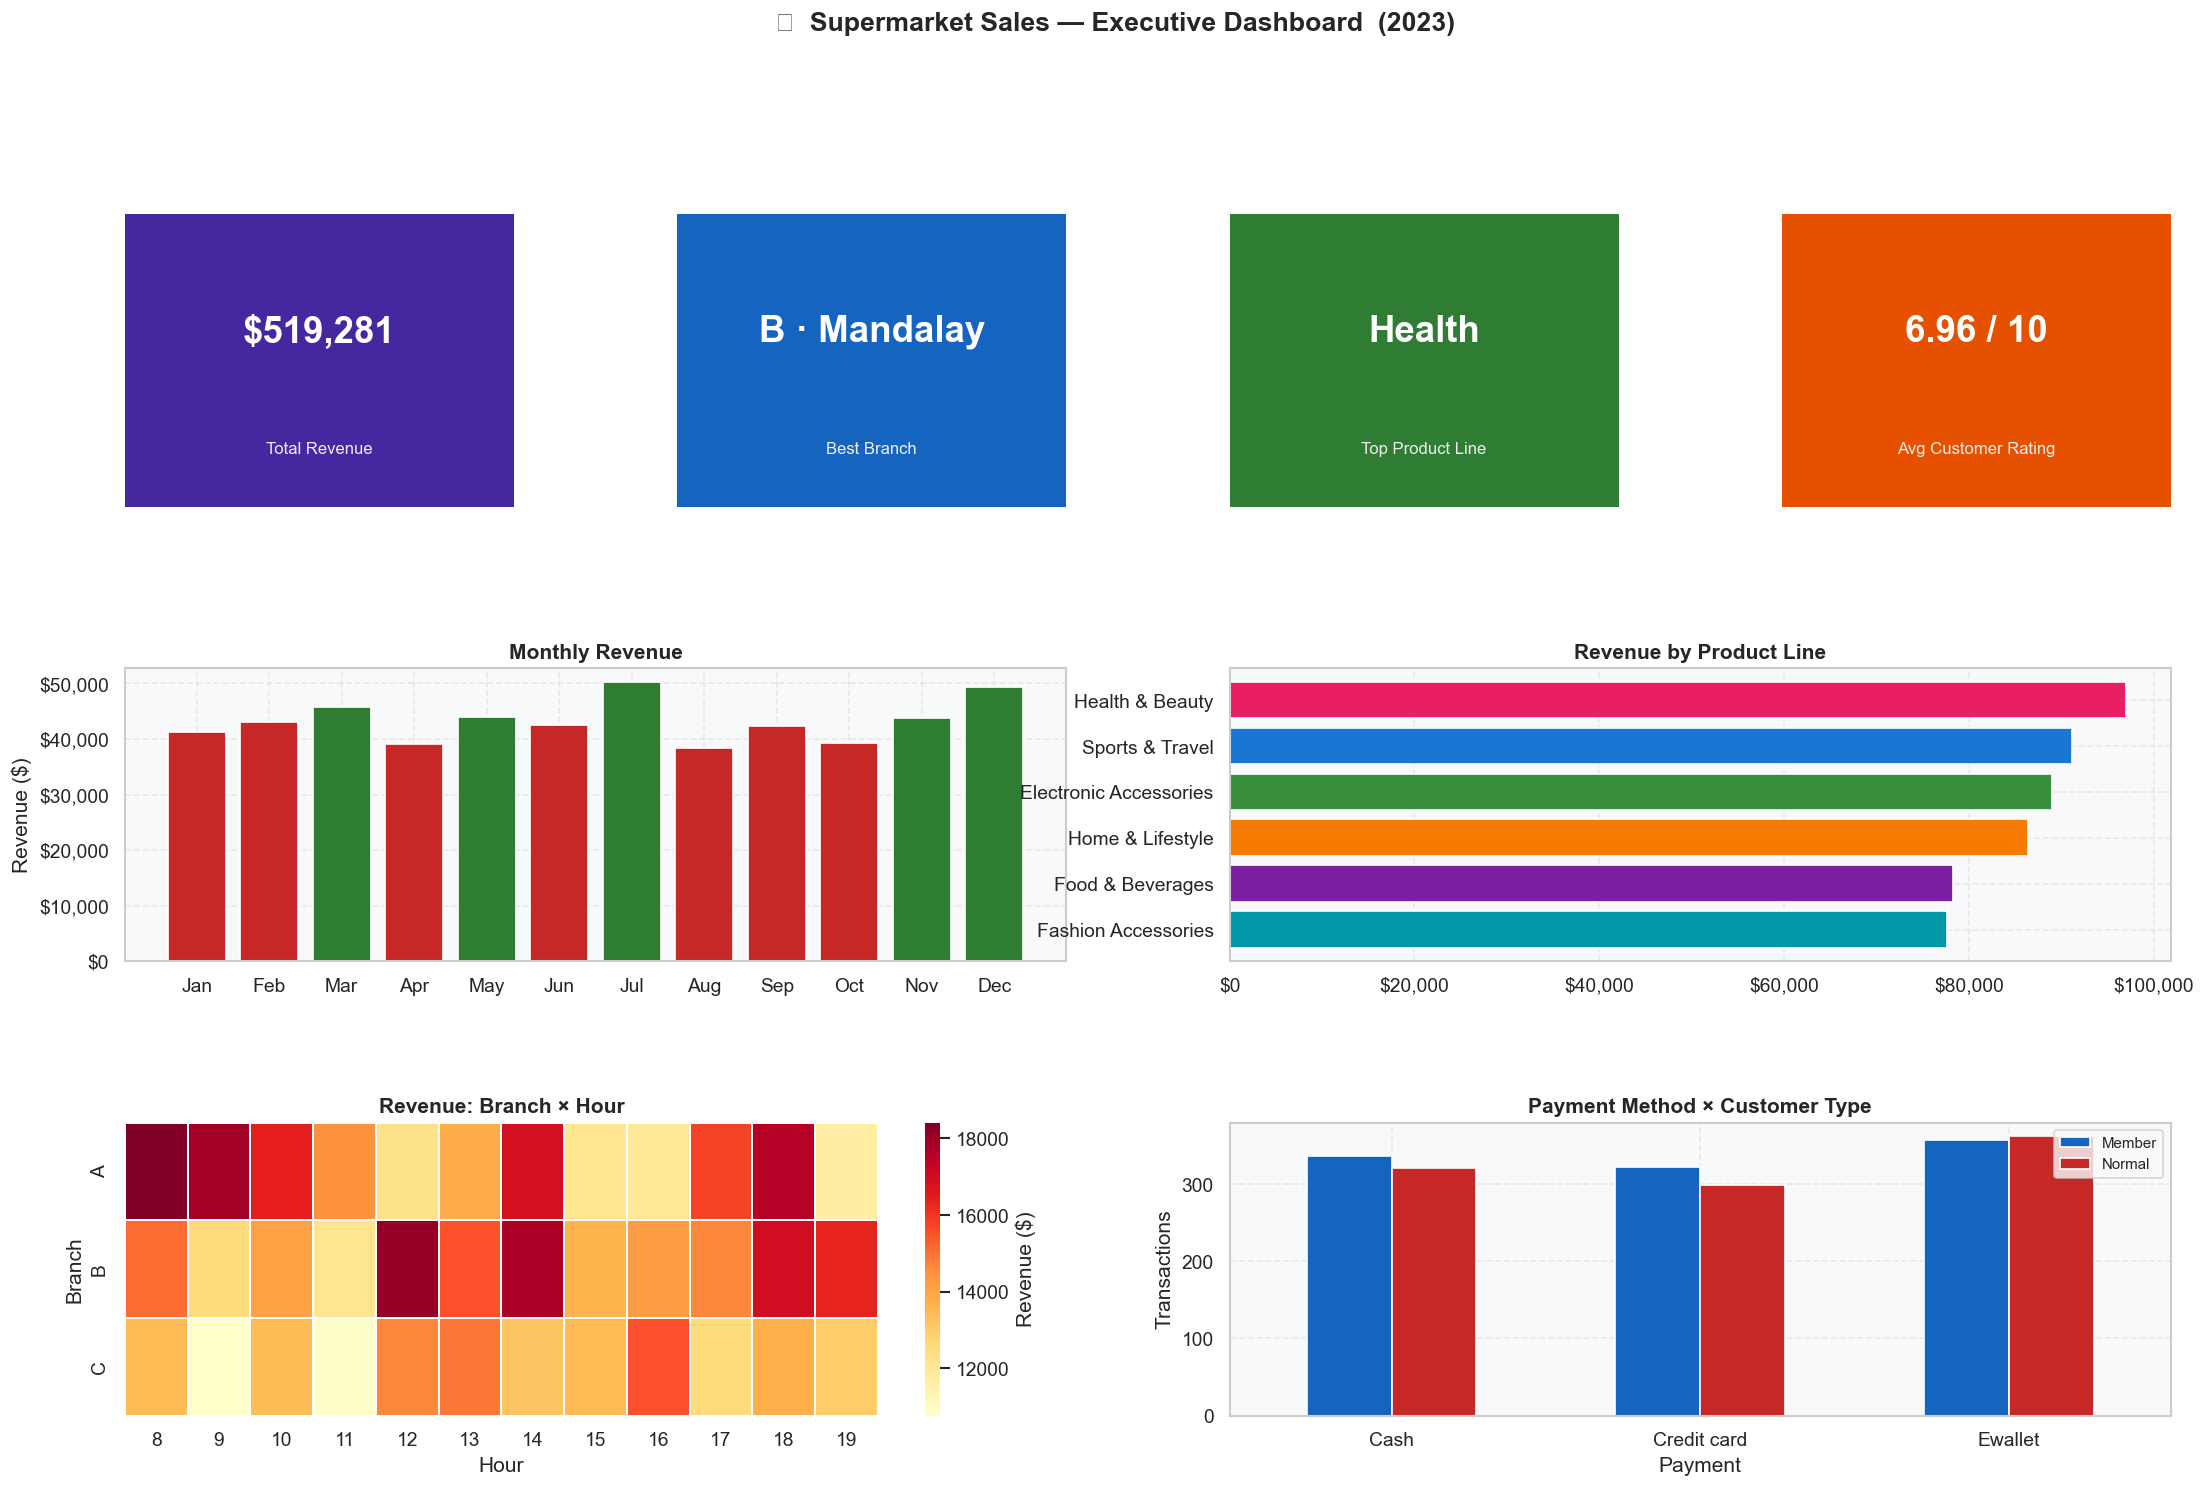

In [21]:
fig = plt.figure(figsize=(22, 13))
fig.patch.set_facecolor('#FFFFFF')
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.42)

# ── KPI Tiles ─────────────────────────────────────────────────────────────
kpis_dash = [
    ('Total Revenue',      f"${df['Total'].sum():,.0f}",        '#4527A0'),
    ('Best Branch',        f"{df.groupby('Branch')['Total'].sum().idxmax()} · {CITY_MAP[df.groupby('Branch')['Total'].sum().idxmax()]}", '#1565C0'),
    ('Top Product Line',   df.groupby('Product_Line')['Total'].sum().idxmax().split(' & ')[0], '#2E7D32'),
    ('Avg Customer Rating',f"{df['Rating'].mean():.2f} / 10",   '#E65100'),
]
for i, (label, val, color) in enumerate(kpis_dash):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(color)
    fsize = 18 if len(str(val)) > 12 else 22
    ax.text(0.5, 0.60, val,   ha='center', va='center',
            fontsize=fsize, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.20, label, ha='center', va='center',
            fontsize=10, color='#EEEEEE', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)

# ── Monthly revenue ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0:2])
monthly_d = df.groupby('Month')['Total'].sum()
bar_cols_d = [PAL['positive'] if v >= monthly_d.mean() else PAL['negative']
              for v in monthly_d.values]
ax1.bar(MONTH_ABBR, monthly_d.values, color=bar_cols_d, edgecolor='white')
ax1.set_title('Monthly Revenue', fontweight='bold')
ax1.set_ylabel('Revenue ($)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# ── Product line revenue ──────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 2:4])
prod_d = df.groupby('Product_Line')['Total'].sum().sort_values()
ax2.barh(prod_d.index, prod_d.values,
         color=[PRODUCT_COLORS[p] for p in prod_d.index], edgecolor='white')
ax2.set_title('Revenue by Product Line', fontweight='bold')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# ── Hourly heatmap across branches ───────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0:2])
branch_hour = df.groupby(['Branch','Hour'])['Total'].sum().unstack(fill_value=0)
sns.heatmap(branch_hour, cmap='YlOrRd', ax=ax3,
            cbar_kws={'label':'Revenue ($)'}, linewidths=0.2)
ax3.set_title('Revenue: Branch × Hour', fontweight='bold')
ax3.set_xlabel('Hour'); ax3.set_ylabel('Branch')

# ── Payment & customer type ───────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 2:4])
pay_ct = df.groupby(['Payment','Customer_Type']).size().unstack(fill_value=0)
pay_ct.plot(kind='bar', ax=ax4, color=['#1565C0','#C62828'],
            edgecolor='white', width=0.55)
ax4.set_title('Payment Method × Customer Type', fontweight='bold')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)
ax4.set_ylabel('Transactions')
ax4.legend(fontsize=9)

fig.suptitle('🛒  Supermarket Sales — Executive Dashboard  (2023)',
             fontsize=16, fontweight='bold', y=1.01)
fig.savefig(os.path.join(OUTPUT_DIR,'figures','dashboard.png'),
            dpi=150, bbox_inches='tight')
plt.show()


In [22]:
from scipy.stats import kruskal, mannwhitneyu, f_oneway

print('='*65)
print('  STATISTICAL SIGNIFICANCE TESTS')
print('='*65)

# 1. Revenue across branches
grps = [df[df['Branch']==b]['Total'] for b in ['A','B','C']]
stat, p = kruskal(*grps)
print(f'\n1. Kruskal-Wallis: Revenue across branches')
print(f'   H={stat:.3f}, p={p:.4f} → '
      f'{"Significant ✅" if p<0.05 else "Not significant ❌"}')

# 2. Member vs Normal spend
m_s = df[df['Customer_Type']=='Member']['Total']
n_s = df[df['Customer_Type']=='Normal']['Total']
stat2, p2 = mannwhitneyu(m_s, n_s, alternative='two-sided')
print(f'\n2. Mann-Whitney U: Member vs Normal spend')
print(f'   U={stat2:.0f}, p={p2:.4f} → '
      f'{"Significant ✅" if p2<0.05 else "Not significant ❌"}')
print(f'   Member avg=${m_s.mean():.2f}  Normal avg=${n_s.mean():.2f}')

# 3. Rating across product lines
grps_r = [df[df['Product_Line']==pl]['Rating']
          for pl in df['Product_Line'].unique()]
stat3, p3 = kruskal(*grps_r)
print(f'\n3. Kruskal-Wallis: Rating across product lines')
print(f'   H={stat3:.3f}, p={p3:.4f} → '
      f'{"Significant ✅" if p3<0.05 else "Not significant ❌"}')

# 4. Weekend vs weekday spend
wknd = df[df['Is_Weekend']==True ]['Total']
wkdy = df[df['Is_Weekend']==False]['Total']
stat4, p4 = mannwhitneyu(wknd, wkdy, alternative='two-sided')
print(f'\n4. Mann-Whitney U: Weekend vs Weekday spend')
print(f'   U={stat4:.0f}, p={p4:.4f} → '
      f'{"Significant ✅" if p4<0.05 else "Not significant ❌"}')
print(f'   Weekend avg=${wknd.mean():.2f}  Weekday avg=${wkdy.mean():.2f}')

# 5. Pearson: Spend vs Rating
r, p5 = stats.pearsonr(df['Total'], df['Rating'])
print(f'\n5. Pearson: Spend vs Rating')
print(f'   r={r:.4f}, p={p5:.4f} → '
      f'{"Significant ✅" if p5<0.05 else "Not significant ❌"}')
print('='*65)


  STATISTICAL SIGNIFICANCE TESTS

1. Kruskal-Wallis: Revenue across branches
   H=2.684, p=0.2613 → Not significant ❌

2. Mann-Whitney U: Member vs Normal spend
   U=489779, p=0.4359 → Not significant ❌
   Member avg=$257.29  Normal avg=$262.08

3. Kruskal-Wallis: Rating across product lines
   H=2.186, p=0.8228 → Not significant ❌

4. Mann-Whitney U: Weekend vs Weekday spend
   U=380760, p=0.8517 → Not significant ❌
   Weekend avg=$258.71  Weekday avg=$259.96

5. Pearson: Spend vs Rating
   r=-0.0092, p=0.6802 → Not significant ❌
